# DS 5110: Final Project

## Predicting FIFA World Cup Advancement Using Machine Learning

### Course
**DS 5110 – Data Science**

### Team Members
- Joseph Bannon
- Sarah Christen
- Carlos Canales

### Project Overview

This project develops and evaluates machine learning models to predict FIFA World Cup team advancement using historical tournament data. Historical performance statistics, FIFA rankings, Elo ratings, squad market values, and previous World Cup experience are combined to train and compare three classification algorithms:

- Logistic Regression
- Random Forest
- Gradient Boosted Trees

Models are evaluated using a chronological train-test split, with the 2022 FIFA World Cup serving as the held-out test set. The best-performing model is then applied to generate probabilistic predictions for the 2026 FIFA World Cup.

## Table of Contents

1. Data Loading
2. Data Quality Assessment
3. Load & Validate Elo Ratings
4. Feature Engineering
5. Train, Test, and Prediction Split
6. Exploratory Data Analysis
7. Spark ML Preprocessing Pipeline
8. Logistic Regression Benchmark
9. Logistic Regression Evaluation
10. Random Forest Models
11. Gradient Boosted Trees Models
12. Model Comparison & Champion Model Selection
13. 2026 FIFA World Cup Predictions
14. Conclusion

## 1.  Data Loading: Load historical and 2026 datasets

This notebook develops PySpark models to predict whether each national team
will reach four milestones at the 2026 FIFA World Cup:

- Quarter-final
- Semi-final
- Final
- Champion

The historical dataset contains one row per team per World Cup edition and
includes known tournament outcomes. The 2026 dataset contains the same
predictor columns, but its outcome columns are unknown because the tournament
has not yet occurred.

This section:

1. Starts a Spark session.
2. Loads the historical and 2026 CSV files.
3. Checks dataset dimensions, schemas, and sample records.
4. Confirms that the historical labels are present and the 2026 labels are null.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType,
    StructField,
    IntegerType,
    DoubleType,
    StringType
)

spark = (
    SparkSession.builder
    .appName("WorldCup2026Prediction")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/23 11:19:45 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.0.0


In [2]:
HISTORICAL_DATA_PATH = "train_wc_places.csv"
WORLD_CUP_2026_DATA_PATH = "test_wc_places.csv"

world_cup_schema = StructType([
    StructField("version", IntegerType(), True),
    StructField("team", StringType(), True),
    StructField("continent", StringType(), True),
    StructField("is_host", IntegerType(), True),
    StructField("goals_scored_last_4y", IntegerType(), True),
    StructField("goals_received_last_4y", IntegerType(), True),
    StructField("wins_last_4y", IntegerType(), True),
    StructField("losses_last_4y", IntegerType(), True),
    StructField("draws_last_4y", IntegerType(), True),
    StructField("world_cup_titles_before", IntegerType(), True),
    StructField("squad_total_market_value_eur", DoubleType(), True),
    StructField("fifa_rank_pre_tournament", IntegerType(), True),
    StructField("fifa_points_pre_tournament", DoubleType(), True),
    StructField("squad_avg_age", DoubleType(), True),
    StructField("world_cup_participations_before", IntegerType(), True),
    StructField("groups_passed_before", IntegerType(), True),
    StructField("round16_before", IntegerType(), True),
    StructField("quarterfinals_before", IntegerType(), True),
    StructField("semifinals_before", IntegerType(), True),
    StructField("finals_before", IntegerType(), True),
    StructField("winner", IntegerType(), True),
    StructField("finalist", IntegerType(), True),
    StructField("semi_finalist", IntegerType(), True),
    StructField("quarter_finalist", IntegerType(), True)
])

In [3]:
historical_df = (
    spark.read
    .option("header", True)
    .option("mode", "FAILFAST")
    .schema(world_cup_schema)
    .csv(HISTORICAL_DATA_PATH)
)

world_cup_2026_df = (
    spark.read
    .option("header", True)
    .option("mode", "FAILFAST")
    .schema(world_cup_schema)
    .csv(WORLD_CUP_2026_DATA_PATH)
)

In [4]:
def print_dimensions(df, dataset_name):
    row_count = df.count()
    column_count = len(df.columns)

    print(f"{dataset_name}: {row_count} rows × {column_count} columns")


print_dimensions(historical_df, "Historical dataset")
print_dimensions(world_cup_2026_df, "2026 prediction dataset")

Historical dataset: 192 rows × 24 columns
2026 prediction dataset: 48 rows × 24 columns


In [5]:
historical_df.show(5, truncate=False)

+-------+----------+-------------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+------------------------+--------------------------+-------------+-------------------------------+--------------------+--------------+--------------------+-----------------+-------------+------+--------+-------------+----------------+
|version|team      |continent    |is_host|goals_scored_last_4y|goals_received_last_4y|wins_last_4y|losses_last_4y|draws_last_4y|world_cup_titles_before|squad_total_market_value_eur|fifa_rank_pre_tournament|fifa_points_pre_tournament|squad_avg_age|world_cup_participations_before|groups_passed_before|round16_before|quarterfinals_before|semifinals_before|finals_before|winner|finalist|semi_finalist|quarter_finalist|
+-------+----------+-------------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------

In [6]:
world_cup_2026_df.show(5, truncate=False)

+-------+---------+-------------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+------------------------+--------------------------+-------------+-------------------------------+--------------------+--------------+--------------------+-----------------+-------------+------+--------+-------------+----------------+
|version|team     |continent    |is_host|goals_scored_last_4y|goals_received_last_4y|wins_last_4y|losses_last_4y|draws_last_4y|world_cup_titles_before|squad_total_market_value_eur|fifa_rank_pre_tournament|fifa_points_pre_tournament|squad_avg_age|world_cup_participations_before|groups_passed_before|round16_before|quarterfinals_before|semifinals_before|finals_before|winner|finalist|semi_finalist|quarter_finalist|
+-------+---------+-------------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+-------------------

In [7]:
print("Historical dataset schema")
historical_df.printSchema()

print("2026 prediction dataset schema")
world_cup_2026_df.printSchema()

Historical dataset schema
root
 |-- version: integer (nullable = true)
 |-- team: string (nullable = true)
 |-- continent: string (nullable = true)
 |-- is_host: integer (nullable = true)
 |-- goals_scored_last_4y: integer (nullable = true)
 |-- goals_received_last_4y: integer (nullable = true)
 |-- wins_last_4y: integer (nullable = true)
 |-- losses_last_4y: integer (nullable = true)
 |-- draws_last_4y: integer (nullable = true)
 |-- world_cup_titles_before: integer (nullable = true)
 |-- squad_total_market_value_eur: double (nullable = true)
 |-- fifa_rank_pre_tournament: integer (nullable = true)
 |-- fifa_points_pre_tournament: double (nullable = true)
 |-- squad_avg_age: double (nullable = true)
 |-- world_cup_participations_before: integer (nullable = true)
 |-- groups_passed_before: integer (nullable = true)
 |-- round16_before: integer (nullable = true)
 |-- quarterfinals_before: integer (nullable = true)
 |-- semifinals_before: integer (nullable = true)
 |-- finals_before: int

In [8]:
print("Historical tournament years:")
historical_df.select("version").distinct().orderBy("version").show()

print("2026 dataset tournament years:")
world_cup_2026_df.select("version").distinct().orderBy("version").show()

Historical tournament years:
+-------+
|version|
+-------+
|   2002|
|   2006|
|   2010|
|   2014|
|   2018|
|   2022|
+-------+

2026 dataset tournament years:
+-------+
|version|
+-------+
|   2026|
+-------+



In [9]:
target_columns = [
    "quarter_finalist",
    "semi_finalist",
    "finalist",
    "winner"
]

historical_df.select([
    F.sum(F.col(column)).alias(column)
    for column in target_columns
]).show()

+----------------+-------------+--------+------+
|quarter_finalist|semi_finalist|finalist|winner|
+----------------+-------------+--------+------+
|              48|           24|      12|     6|
+----------------+-------------+--------+------+



In [10]:
non_null_2026_labels = (
    world_cup_2026_df
    .select([
        F.count(F.when(F.col(column).isNotNull(), column)).alias(column)
        for column in target_columns
    ])
    .first()
    .asDict()
)

assert all(count == 0 for count in non_null_2026_labels.values()), (
    "At least one 2026 outcome column unexpectedly contains a value."
)

print("2026 outcome columns are correctly empty.")

2026 outcome columns are correctly empty.


In [11]:
historical_raw_df = historical_df
prediction_2026_raw_df = world_cup_2026_df

## 2. Data Quality Assessment

Before preprocessing, we inspect the historical and 2026 datasets for
potential issues.

Specifically we check:

- duplicate rows
- missing values
- label consistency
- numeric ranges
- categorical values

This allows us to identify cleaning steps before feature engineering.

In [12]:
historical_rows = historical_raw_df.count()
historical_unique = historical_raw_df.dropDuplicates().count()

print(f"Historical rows: {historical_rows}")
print(f"Unique rows:      {historical_unique}")
print(f"Duplicates:       {historical_rows - historical_unique}")

Historical rows: 192
Unique rows:      192
Duplicates:       0


In [13]:
prediction_rows = prediction_2026_raw_df.count()
prediction_unique = prediction_2026_raw_df.dropDuplicates().count()

print(f"2026 rows:        {prediction_rows}")
print(f"Unique rows:      {prediction_unique}")
print(f"Duplicates:       {prediction_rows - prediction_unique}")

2026 rows:        48
Unique rows:      48
Duplicates:       0


In [14]:
def missing_summary(df):

    total = df.count()

    missing = (
        df.select([
            F.sum(
                F.when(
                    F.col(c).isNull() | F.isnan(c),
                    1
                ).otherwise(0)
            ).alias(c)
            for c, t in df.dtypes
            if t in ("double", "float")
        ] + [
            F.sum(
                F.when(F.col(c).isNull(),1).otherwise(0)
            ).alias(c)
            for c, t in df.dtypes
            if t not in ("double","float")
        ])
    )

    return missing

missing_summary(historical_raw_df).show(vertical=True)

-RECORD 0------------------------------
 squad_total_market_value_eur    | 32  
 fifa_points_pre_tournament      | 0   
 squad_avg_age                   | 0   
 version                         | 0   
 team                            | 0   
 continent                       | 0   
 is_host                         | 0   
 goals_scored_last_4y            | 0   
 goals_received_last_4y          | 0   
 wins_last_4y                    | 0   
 losses_last_4y                  | 0   
 draws_last_4y                   | 0   
 world_cup_titles_before         | 0   
 fifa_rank_pre_tournament        | 0   
 world_cup_participations_before | 0   
 groups_passed_before            | 0   
 round16_before                  | 0   
 quarterfinals_before            | 0   
 semifinals_before               | 0   
 finals_before                   | 0   
 winner                          | 0   
 finalist                        | 0   
 semi_finalist                   | 0   
 quarter_finalist                | 0   


In [15]:
historical_raw_df.filter(
    F.col("squad_total_market_value_eur").isNull()
).select(
    "version",
    "team",
    "continent"
).orderBy("version", "team").show(50, truncate=False)

+-------+-------------------+-------------+
|version|team               |continent    |
+-------+-------------------+-------------+
|2002   |Argentina          |South America|
|2002   |Belgium            |Europe       |
|2002   |Brazil             |South America|
|2002   |Cameroon           |Africa       |
|2002   |China PR           |Asia         |
|2002   |Costa Rica         |North America|
|2002   |Croatia            |Europe       |
|2002   |Denmark            |Europe       |
|2002   |Ecuador            |South America|
|2002   |England            |Europe       |
|2002   |France             |Europe       |
|2002   |Germany            |Europe       |
|2002   |Italy              |Europe       |
|2002   |Japan              |Asia         |
|2002   |Mexico             |North America|
|2002   |Nigeria            |Africa       |
|2002   |Paraguay           |South America|
|2002   |Poland             |Europe       |
|2002   |Portugal           |Europe       |
|2002   |Republic of Ireland|Eur

### Missing Values

The only predictor with missing values is `squad_total_market_value_eur`.

All 32 missing observations correspond to teams from the 2002 FIFA World Cup.
This reflects the lack of reliable historical Transfermarkt market value data for
that tournament rather than errors in the dataset.

Since these observations are otherwise complete and represent one-sixth of the
historical training data, they will be retained. Missing values will be imputed
within the Spark ML pipeline using median imputation.

In [16]:
missing_summary(prediction_2026_raw_df).show(vertical=True)

-RECORD 0------------------------------
 squad_total_market_value_eur    | 0   
 fifa_points_pre_tournament      | 0   
 squad_avg_age                   | 0   
 version                         | 0   
 team                            | 0   
 continent                       | 0   
 is_host                         | 0   
 goals_scored_last_4y            | 0   
 goals_received_last_4y          | 0   
 wins_last_4y                    | 0   
 losses_last_4y                  | 0   
 draws_last_4y                   | 0   
 world_cup_titles_before         | 0   
 fifa_rank_pre_tournament        | 0   
 world_cup_participations_before | 0   
 groups_passed_before            | 0   
 round16_before                  | 0   
 quarterfinals_before            | 0   
 semifinals_before               | 0   
 finals_before                   | 0   
 winner                          | 48  
 finalist                        | 48  
 semi_finalist                   | 48  
 quarter_finalist                | 48  


In [17]:
for target in target_columns:

    print(target)

    historical_raw_df.groupBy(target).count().show()

quarter_finalist
+----------------+-----+
|quarter_finalist|count|
+----------------+-----+
|               1|   48|
|               0|  144|
+----------------+-----+

semi_finalist
+-------------+-----+
|semi_finalist|count|
+-------------+-----+
|            1|   24|
|            0|  168|
+-------------+-----+

finalist
+--------+-----+
|finalist|count|
+--------+-----+
|       1|   12|
|       0|  180|
+--------+-----+

winner
+------+-----+
|winner|count|
+------+-----+
|     1|    6|
|     0|  186|
+------+-----+



In [18]:
historical_raw_df.filter(
    (F.col("winner") == 1) &
    (
        (F.col("finalist") != 1) |
        (F.col("semi_finalist") != 1) |
        (F.col("quarter_finalist") != 1)
    )
).show()

+-------+----+---------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+------------------------+--------------------------+-------------+-------------------------------+--------------------+--------------+--------------------+-----------------+-------------+------+--------+-------------+----------------+
|version|team|continent|is_host|goals_scored_last_4y|goals_received_last_4y|wins_last_4y|losses_last_4y|draws_last_4y|world_cup_titles_before|squad_total_market_value_eur|fifa_rank_pre_tournament|fifa_points_pre_tournament|squad_avg_age|world_cup_participations_before|groups_passed_before|round16_before|quarterfinals_before|semifinals_before|finals_before|winner|finalist|semi_finalist|quarter_finalist|
+-------+----+---------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+-----------------

In [19]:
historical_raw_df.filter(
    (F.col("finalist") == 1) &
    (
        (F.col("semi_finalist") != 1) |
        (F.col("quarter_finalist") != 1)
    )
).show()

+-------+----+---------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+------------------------+--------------------------+-------------+-------------------------------+--------------------+--------------+--------------------+-----------------+-------------+------+--------+-------------+----------------+
|version|team|continent|is_host|goals_scored_last_4y|goals_received_last_4y|wins_last_4y|losses_last_4y|draws_last_4y|world_cup_titles_before|squad_total_market_value_eur|fifa_rank_pre_tournament|fifa_points_pre_tournament|squad_avg_age|world_cup_participations_before|groups_passed_before|round16_before|quarterfinals_before|semifinals_before|finals_before|winner|finalist|semi_finalist|quarter_finalist|
+-------+----+---------+-------+--------------------+----------------------+------------+--------------+-------------+-----------------------+----------------------------+-----------------

In [20]:
numeric_columns = [

    "goals_scored_last_4y",
    "goals_received_last_4y",
    "wins_last_4y",
    "losses_last_4y",
    "draws_last_4y",
    "world_cup_titles_before",
    "squad_total_market_value_eur",
    "fifa_rank_pre_tournament",
    "fifa_points_pre_tournament",
    "squad_avg_age",
    "world_cup_participations_before",
    "groups_passed_before",
    "round16_before",
    "quarterfinals_before",
    "semifinals_before",
    "finals_before"
]

historical_raw_df.select(numeric_columns).describe().show()

26/07/23 11:20:14 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+-------+--------------------+----------------------+-----------------+------------------+------------------+-----------------------+----------------------------+------------------------+--------------------------+------------------+-------------------------------+--------------------+------------------+--------------------+------------------+------------------+
|summary|goals_scored_last_4y|goals_received_last_4y|     wins_last_4y|    losses_last_4y|     draws_last_4y|world_cup_titles_before|squad_total_market_value_eur|fifa_rank_pre_tournament|fifa_points_pre_tournament|     squad_avg_age|world_cup_participations_before|groups_passed_before|    round16_before|quarterfinals_before| semifinals_before|     finals_before|
+-------+--------------------+----------------------+-----------------+------------------+------------------+-----------------------+----------------------------+------------------------+--------------------------+------------------+-------------------------------+-----

In [21]:
historical_raw_df.groupBy("continent") \
    .count() \
    .orderBy("continent") \
    .show()

+-------------+-----+
|    continent|count|
+-------------+-----+
|       Africa|   31|
|         Asia|   23|
|       Europe|   82|
|North America|   21|
|      Oceania|    6|
|South America|   29|
+-------------+-----+



In [22]:
historical_raw_df.groupBy("is_host").count().show()

+-------+-----+
|is_host|count|
+-------+-----+
|      1|    7|
|      0|  185|
+-------+-----+



In [23]:
historical_raw_df.select("team") \
    .distinct() \
    .orderBy("team") \
    .show(300, truncate=False)

+----------------------+
|team                  |
+----------------------+
|Algeria               |
|Angola                |
|Argentina             |
|Australia             |
|Belgium               |
|Bosnia and Herzegovina|
|Brazil                |
|Cameroon              |
|Canada                |
|Chile                 |
|China PR              |
|Colombia              |
|Costa Rica            |
|Croatia               |
|Czech Republic        |
|Denmark               |
|Ecuador               |
|Egypt                 |
|England               |
|France                |
|Germany               |
|Ghana                 |
|Greece                |
|Honduras              |
|Iceland               |
|Iran                  |
|Italy                 |
|Ivory Coast           |
|Japan                 |
|Mexico                |
|Morocco               |
|Netherlands           |
|New Zealand           |
|Nigeria               |
|North Korea           |
|Panama                |
|Paraguay              |


In [24]:
prediction_2026_raw_df.select("team") \
    .distinct() \
    .orderBy("team") \
    .show(100, truncate=False)

+----------------------+
|team                  |
+----------------------+
|Algeria               |
|Argentina             |
|Australia             |
|Austria               |
|Belgium               |
|Bosnia and Herzegovina|
|Brazil                |
|Canada                |
|Cape Verde            |
|Colombia              |
|Croatia               |
|Cura?o                |
|Czech Republic        |
|DR Congo              |
|Ecuador               |
|Egypt                 |
|England               |
|France                |
|Germany               |
|Ghana                 |
|Haiti                 |
|Iran                  |
|Iraq                  |
|Ivory Coast           |
|Japan                 |
|Jordan                |
|Mexico                |
|Morocco               |
|Netherlands           |
|New Zealand           |
|Norway                |
|Panama                |
|Paraguay              |
|Portugal              |
|Qatar                 |
|Saudi Arabia          |
|Scotland              |


## 3. Load and Validate Elo Ratings

The Elo ratings dataset provides an additional measure of team strength.

Before joining it to the historical and 2026 datasets, we verify:

- schema
- row count
- duplicate teams
- missing values
- team-name consistency

This helps prevent failed joins caused by inconsistent country names.

In [25]:
elo_path = "elo_ratings_wc2026.csv"

elo_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(elo_path)
)

In [26]:
print(f"Rows: {elo_df.count()}")
print(f"Columns: {len(elo_df.columns)}")

elo_df.printSchema()

elo_df.show(10, truncate=False)

Rows: 4683
Columns: 23
root
 |-- year: integer (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- country: string (nullable = true)
 |-- rank: integer (nullable = true)
 |-- country_code: string (nullable = true)
 |-- rating: integer (nullable = true)
 |-- rank_max: integer (nullable = true)
 |-- rating_max: integer (nullable = true)
 |-- rank_avg: integer (nullable = true)
 |-- rating_avg: integer (nullable = true)
 |-- rank_min: integer (nullable = true)
 |-- rating_min: integer (nullable = true)
 |-- matches_total: integer (nullable = true)
 |-- matches_home: integer (nullable = true)
 |-- matches_away: integer (nullable = true)
 |-- matches_neutral: integer (nullable = true)
 |-- wins: integer (nullable = true)
 |-- losses: integer (nullable = true)
 |-- draws: integer (nullable = true)
 |-- goals_for: integer (nullable = true)
 |-- goals_against: integer (nullable = true)
 |-- confederation: string (nullable = true)
 |-- is_host: integer (nullable = true)

+----+---

In [27]:
historical_df = historical_raw_df.withColumn(
    "elo_year",
    F.col("version") - 1
)

prediction_df = prediction_2026_raw_df.withColumn(
    "elo_year",
    F.col("version") - 1
)

In [28]:
elo_features = (
    elo_df.select(
        F.col("year").alias("elo_year"),
        F.col("country").alias("team"),
        "rating",
        "rating_avg",
        "rating_max",
        "rating_min"
    )
)

In [29]:
used_elo_years = [2001, 2005, 2009, 2013, 2017, 2021, 2025]

elo_features.filter(
    F.col("elo_year").isin(used_elo_years)
).groupBy(
    "elo_year",
    "team"
).count().filter(
    F.col("count") > 1
).show()

+--------+----+-----+
|elo_year|team|count|
+--------+----+-----+
+--------+----+-----+



In [30]:
historical_teams = {
    row.team
    for row in historical_df.select("team").distinct().collect()
}

elo_teams = {
    row.team
    for row in elo_features.select("team").distinct().collect()
}

print("Historical teams missing from Elo:")
print(sorted(historical_teams - elo_teams))

print("\nElo teams not in historical data:")
print(sorted(elo_teams - historical_teams))

Historical teams missing from Elo:
['Angola', 'Cameroon', 'Chile', 'China PR', 'Costa Rica', 'Czech Republic', 'Denmark', 'Greece', 'Honduras', 'Iceland', 'Italy', 'Nigeria', 'North Korea', 'Peru', 'Poland', 'Republic of Ireland', 'Russia', 'Serbia', 'Serbia and Montenegro', 'Slovakia', 'Slovenia', 'Togo', 'Trinidad and Tobago', 'Ukraine', 'Wales']

Elo teams not in historical data:
['Austria', 'Cape Verde', 'Curaçao', 'Czechia', 'DR Congo', 'Haiti', 'Iraq', 'Jordan', 'Norway', 'Scotland', 'Uzbekistan']


In [31]:
elo_df.select("country").distinct().count()

48

In [32]:
elo_df.filter(
    F.col("year") == 2026
).select(
    "country"
).distinct().orderBy("country").show(100, truncate=False)

+----------------------+
|country               |
+----------------------+
|Algeria               |
|Argentina             |
|Australia             |
|Austria               |
|Belgium               |
|Bosnia and Herzegovina|
|Brazil                |
|Canada                |
|Cape Verde            |
|Colombia              |
|Croatia               |
|Curaçao               |
|Czechia               |
|DR Congo              |
|Ecuador               |
|Egypt                 |
|England               |
|France                |
|Germany               |
|Ghana                 |
|Haiti                 |
|Iran                  |
|Iraq                  |
|Ivory Coast           |
|Japan                 |
|Jordan                |
|Mexico                |
|Morocco               |
|Netherlands           |
|New Zealand           |
|Norway                |
|Panama                |
|Paraguay              |
|Portugal              |
|Qatar                 |
|Saudi Arabia          |
|Scotland              |


In [33]:
for year in [2025, 2026]:
    country_count = (
        elo_df
        .filter(F.col("year") == year)
        .select("country")
        .distinct()
        .count()
    )

    print(f"{year}: {country_count} countries")

2025: 48 countries
2026: 48 countries


In [34]:
historical_df = (
    historical_raw_df
    .withColumn("elo_year", F.col("version") - 1)
    .withColumn(
        "elo_country",
        F.when(F.col("team") == "Czech Republic", "Czechia")
         .when(F.col("team") == "Cura?o", "Curaçao")
         .otherwise(F.col("team"))
    )
)

prediction_df = (
    prediction_2026_raw_df
    .withColumn("elo_year", F.col("version") - 1)
    .withColumn(
        "elo_country",
        F.when(F.col("team") == "Czech Republic", "Czechia")
         .when(F.col("team") == "Cura?o", "Curaçao")
         .otherwise(F.col("team"))
    )
)

In [35]:
prediction_elo_names = {
    row.elo_country
    for row in prediction_df.select("elo_country").distinct().collect()
}

elo_2025_names = {
    row.country
    for row in elo_df
        .filter(F.col("year") == 2025)
        .select("country")
        .distinct()
        .collect()
}

print("2026 teams missing from 2025 Elo:")
print(sorted(prediction_elo_names - elo_2025_names))

print("\n2025 Elo countries not found in the prediction data:")
print(sorted(elo_2025_names - prediction_elo_names))

2026 teams missing from 2025 Elo:
[]

2025 Elo countries not found in the prediction data:
[]


In [36]:
elo_join_check = (
    historical_df.alias("wc")
    .join(
        elo_features.alias("elo"),
        (F.col("wc.elo_year") == F.col("elo.elo_year")) &
        (F.col("wc.elo_country") == F.col("elo.team")),
        how="left"
    )
)

In [37]:
elo_join_check.groupBy(
    F.col("wc.version").alias("version")
).agg(
    F.count("*").alias("total_teams"),
    F.sum(
        F.when(F.col("elo.rating").isNotNull(), 1).otherwise(0)
    ).alias("matched_elo"),
    F.sum(
        F.when(F.col("elo.rating").isNull(), 1).otherwise(0)
    ).alias("missing_elo")
).withColumn(
    "match_rate",
    F.round(F.col("matched_elo") / F.col("total_teams"), 3)
).orderBy("version").show()

+-------+-----------+-----------+-----------+----------+
|version|total_teams|matched_elo|missing_elo|match_rate|
+-------+-----------+-----------+-----------+----------+
|   2002|         32|         22|         10|     0.688|
|   2006|         32|         24|          8|      0.75|
|   2010|         32|         21|         11|     0.656|
|   2014|         32|         24|          8|      0.75|
|   2018|         32|         24|          8|      0.75|
|   2022|         32|         26|          6|     0.813|
+-------+-----------+-----------+-----------+----------+



In [38]:
elo_join_check.filter(
    F.col("elo.rating").isNull()
).select(
    F.col("wc.version").alias("version"),
    F.col("wc.team").alias("team"),
    F.col("wc.elo_year").alias("elo_year")
).orderBy("version", "team").show(200, truncate=False)

+-------+---------------------+--------+
|version|team                 |elo_year|
+-------+---------------------+--------+
|2002   |Cameroon             |2001    |
|2002   |China PR             |2001    |
|2002   |Costa Rica           |2001    |
|2002   |Denmark              |2001    |
|2002   |Italy                |2001    |
|2002   |Nigeria              |2001    |
|2002   |Poland               |2001    |
|2002   |Republic of Ireland  |2001    |
|2002   |Russia               |2001    |
|2002   |Slovenia             |2001    |
|2006   |Angola               |2005    |
|2006   |Costa Rica           |2005    |
|2006   |Italy                |2005    |
|2006   |Poland               |2005    |
|2006   |Serbia and Montenegro|2005    |
|2006   |Togo                 |2005    |
|2006   |Trinidad and Tobago  |2005    |
|2006   |Ukraine              |2005    |
|2010   |Cameroon             |2009    |
|2010   |Chile                |2009    |
|2010   |Denmark              |2009    |
|2010   |Greece 

In [39]:
historical_joined = (
    historical_df.alias("wc")
    .join(
        elo_features.alias("elo"),
        (F.col("wc.elo_year") == F.col("elo.elo_year")) &
        (F.col("wc.elo_country") == F.col("elo.team")),
        "left"
    )
)

In [40]:
historical_joined = historical_joined.withColumn(
    "elo_missing",
    F.when(
        F.col("rating").isNull(),
        1
    ).otherwise(0)
)

In [41]:
historical_joined = historical_joined.select(
    "wc.*",
    "rating",
    "rating_avg",
    "rating_max",
    "rating_min",
    "elo_missing"
)

In [42]:
historical_joined.select(
    "version",
    "team",
    "rating",
    "rating_avg",
    "elo_missing"
).show(10, truncate=False)

+-------+--------------+------+----------+-----------+
|version|team          |rating|rating_avg|elo_missing|
+-------+--------------+------+----------+-----------+
|2006   |Angola        |NULL  |NULL      |1          |
|2006   |Argentina     |1930  |1981      |0          |
|2006   |Australia     |1765  |1654      |0          |
|2006   |Brazil        |2027  |1981      |0          |
|2006   |Costa Rica    |NULL  |NULL      |1          |
|2006   |Croatia       |1864  |1879      |0          |
|2006   |Czech Republic|1965  |1870      |0          |
|2006   |Ecuador       |1715  |1443      |0          |
|2006   |England       |1963  |1987      |0          |
|2006   |France        |1973  |1757      |0          |
+-------+--------------+------+----------+-----------+
only showing top 10 rows


In [43]:
prediction_joined = (
    prediction_df.alias("wc")
    .join(
        elo_features.alias("elo"),
        (F.col("wc.elo_year") == F.col("elo.elo_year")) &
        (F.col("wc.elo_country") == F.col("elo.team")),
        how="left"
    )
    .select(
        "wc.*",
        "elo.rating",
        "elo.rating_avg",
        "elo.rating_max",
        "elo.rating_min"
    )
    .withColumn(
        "elo_missing",
        F.when(F.col("rating").isNull(), 1).otherwise(0)
    )
)

In [44]:
prediction_joined.select(
    F.count("*").alias("rows"),
    F.sum("elo_missing").alias("missing_elo_rows")
).show()

+----+----------------+
|rows|missing_elo_rows|
+----+----------------+
|  48|               0|
+----+----------------+



In [45]:
assert historical_joined.count() == 192
assert prediction_joined.count() == 48

print("Both joins preserved the expected row counts.")

Both joins preserved the expected row counts.


In [46]:
historical_joined = historical_joined.withColumn(
    "market_value_missing",
    F.when(
        F.col("squad_total_market_value_eur").isNull(),
        1
    ).otherwise(0)
)

prediction_joined = prediction_joined.withColumn(
    "market_value_missing",
    F.when(
        F.col("squad_total_market_value_eur").isNull(),
        1
    ).otherwise(0)
)

In [47]:
historical_joined.groupBy(
    "version"
).agg(
    F.sum("market_value_missing").alias("missing_market_values")
).orderBy("version").show()

+-------+---------------------+
|version|missing_market_values|
+-------+---------------------+
|   2002|                   32|
|   2006|                    0|
|   2010|                    0|
|   2014|                    0|
|   2018|                    0|
|   2022|                    0|
+-------+---------------------+



In [48]:
prediction_joined.groupBy("market_value_missing").count().show()

+--------------------+-----+
|market_value_missing|count|
+--------------------+-----+
|                   0|   48|
+--------------------+-----+



In [49]:
print("Historical modeling data")
print(f"Rows: {historical_joined.count()}")
print(f"Columns: {len(historical_joined.columns)}")

print("\n2026 prediction data")
print(f"Rows: {prediction_joined.count()}")
print(f"Columns: {len(prediction_joined.columns)}")

historical_joined.select(
    "version",
    "team",
    "squad_total_market_value_eur",
    "market_value_missing",
    "rating",
    "elo_missing"
).orderBy("version", "team").show(10, truncate=False)

prediction_joined.select(
    "version",
    "team",
    "rating",
    "elo_missing"
).orderBy("team").show(48, truncate=False)

Historical modeling data
Rows: 192
Columns: 32

2026 prediction data
Rows: 48
Columns: 32
+-------+----------+----------------------------+--------------------+------+-----------+
|version|team      |squad_total_market_value_eur|market_value_missing|rating|elo_missing|
+-------+----------+----------------------------+--------------------+------+-----------+
|2002   |Argentina |NULL                        |1                   |2024  |0          |
|2002   |Belgium   |NULL                        |1                   |1833  |0          |
|2002   |Brazil    |NULL                        |1                   |1833  |0          |
|2002   |Cameroon  |NULL                        |1                   |NULL  |1          |
|2002   |China PR  |NULL                        |1                   |NULL  |1          |
|2002   |Costa Rica|NULL                        |1                   |NULL  |1          |
|2002   |Croatia   |NULL                        |1                   |1885  |0          |
|2002   |D

## 4. Feature Engineering

This section prepares the final modeling datasets.

Tasks include:

- creating missing-value indicator features
- selecting predictor variables
- removing temporary join columns
- defining the target variables
- creating clean historical and prediction datasets

These datasets will be used for train/test splitting and Spark ML pipelines.

In [50]:
historical_joined = historical_joined.withColumn(
    "market_value_missing",
    F.when(
        F.col("squad_total_market_value_eur").isNull(),
        1
    ).otherwise(0)
)

prediction_joined = prediction_joined.withColumn(
    "market_value_missing",
    F.when(
        F.col("squad_total_market_value_eur").isNull(),
        1
    ).otherwise(0)
)

In [51]:
columns_to_drop = [
    "elo_year",
    "elo_country"
]

historical_model_df = historical_joined.drop(*columns_to_drop)
prediction_model_df = prediction_joined.drop(*columns_to_drop)

In [52]:
target_columns = [
    "quarter_finalist",
    "semi_finalist",
    "finalist",
    "winner"
]

In [53]:
feature_columns = [

    "continent",
    "is_host",

    "goals_scored_last_4y",
    "goals_received_last_4y",

    "wins_last_4y",
    "losses_last_4y",
    "draws_last_4y",

    "world_cup_titles_before",

    "squad_total_market_value_eur",
    "market_value_missing",

    "fifa_rank_pre_tournament",
    "fifa_points_pre_tournament",
    "squad_avg_age",

    "world_cup_participations_before",
    "groups_passed_before",
    "round16_before",
    "quarterfinals_before",
    "semifinals_before",
    "finals_before",

    "rating",
    "rating_avg",
    "rating_max",
    "rating_min",
    "elo_missing"
]

In [54]:
historical_model_df.select(
    feature_columns + target_columns
).printSchema()

root
 |-- continent: string (nullable = true)
 |-- is_host: integer (nullable = true)
 |-- goals_scored_last_4y: integer (nullable = true)
 |-- goals_received_last_4y: integer (nullable = true)
 |-- wins_last_4y: integer (nullable = true)
 |-- losses_last_4y: integer (nullable = true)
 |-- draws_last_4y: integer (nullable = true)
 |-- world_cup_titles_before: integer (nullable = true)
 |-- squad_total_market_value_eur: double (nullable = true)
 |-- market_value_missing: integer (nullable = false)
 |-- fifa_rank_pre_tournament: integer (nullable = true)
 |-- fifa_points_pre_tournament: double (nullable = true)
 |-- squad_avg_age: double (nullable = true)
 |-- world_cup_participations_before: integer (nullable = true)
 |-- groups_passed_before: integer (nullable = true)
 |-- round16_before: integer (nullable = true)
 |-- quarterfinals_before: integer (nullable = true)
 |-- semifinals_before: integer (nullable = true)
 |-- finals_before: integer (nullable = true)
 |-- rating: integer (nul

In [55]:
print("Historical rows:", historical_model_df.count())
print("Prediction rows:", prediction_model_df.count())

Historical rows: 192
Prediction rows: 48


In [56]:
missing_summary(
    historical_model_df.select(feature_columns)
).show(vertical=True)

-RECORD 0------------------------------
 squad_total_market_value_eur    | 32  
 fifa_points_pre_tournament      | 0   
 squad_avg_age                   | 0   
 continent                       | 0   
 is_host                         | 0   
 goals_scored_last_4y            | 0   
 goals_received_last_4y          | 0   
 wins_last_4y                    | 0   
 losses_last_4y                  | 0   
 draws_last_4y                   | 0   
 world_cup_titles_before         | 0   
 market_value_missing            | 0   
 fifa_rank_pre_tournament        | 0   
 world_cup_participations_before | 0   
 groups_passed_before            | 0   
 round16_before                  | 0   
 quarterfinals_before            | 0   
 semifinals_before               | 0   
 finals_before                   | 0   
 rating                          | 51  
 rating_avg                      | 51  
 rating_max                      | 51  
 rating_min                      | 51  
 elo_missing                     | 0   


In [57]:
training_data = historical_model_df
prediction_data = prediction_model_df

## 5. Train, Test, and Prediction Split

The data are split chronologically by World Cup edition rather than randomly.

- Training data: 2002–2018
- Test data: 2022
- Future prediction data: 2026

This design reduces temporal leakage and reflects the intended use of the
model: learning from past tournaments and predicting a later tournament.

The 2022 test set is excluded from all model training and hyperparameter
selection. The 2026 data are used only after model development is complete.

In [58]:
training_years = [2002, 2006, 2010, 2014, 2018]
test_year = 2022
prediction_year = 2026

train_df = training_data.filter(
    F.col("version").isin(training_years)
)

test_df = training_data.filter(
    F.col("version") == test_year
)

prediction_2026_df = prediction_data.filter(
    F.col("version") == prediction_year
)

In [59]:
print("Training rows:", train_df.count())
print("Test rows:", test_df.count())
print("2026 prediction rows:", prediction_2026_df.count())

Training rows: 160
Test rows: 32
2026 prediction rows: 48


In [60]:
print("Training years:")
train_df.select("version").distinct().orderBy("version").show()

print("Test years:")
test_df.select("version").distinct().orderBy("version").show()

print("Prediction years:")
prediction_2026_df.select("version").distinct().orderBy("version").show()

Training years:
+-------+
|version|
+-------+
|   2002|
|   2006|
|   2010|
|   2014|
|   2018|
+-------+

Test years:
+-------+
|version|
+-------+
|   2022|
+-------+

Prediction years:
+-------+
|version|
+-------+
|   2026|
+-------+



In [61]:
assert train_df.count() == 160, "Unexpected number of training rows."
assert test_df.count() == 32, "Unexpected number of test rows."
assert prediction_2026_df.count() == 48, "Unexpected number of prediction rows."

assert {
    row["version"]
    for row in train_df.select("version").distinct().collect()
} == set(training_years)

assert {
    row["version"]
    for row in test_df.select("version").distinct().collect()
} == {test_year}

assert {
    row["version"]
    for row in prediction_2026_df.select("version").distinct().collect()
} == {prediction_year}

print("Chronological split checks passed.")

Chronological split checks passed.


In [62]:
def label_distribution(df, dataset_name):
    print(dataset_name)

    df.select([
        F.sum(F.col(target)).alias(f"{target}_positive")
        for target in target_columns
    ]).show()


label_distribution(train_df, "Training data")
label_distribution(test_df, "Test data")

Training data
+-------------------------+----------------------+-----------------+---------------+
|quarter_finalist_positive|semi_finalist_positive|finalist_positive|winner_positive|
+-------------------------+----------------------+-----------------+---------------+
|                       40|                    20|               10|              5|
+-------------------------+----------------------+-----------------+---------------+

Test data
+-------------------------+----------------------+-----------------+---------------+
|quarter_finalist_positive|semi_finalist_positive|finalist_positive|winner_positive|
+-------------------------+----------------------+-----------------+---------------+
|                        8|                     4|                2|              1|
+-------------------------+----------------------+-----------------+---------------+



In [63]:
expected_train_positives = {
    "quarter_finalist": 40,
    "semi_finalist": 20,
    "finalist": 10,
    "winner": 5
}

expected_test_positives = {
    "quarter_finalist": 8,
    "semi_finalist": 4,
    "finalist": 2,
    "winner": 1
}

for target, expected in expected_train_positives.items():
    actual = train_df.filter(F.col(target) == 1).count()
    assert actual == expected, (
        f"{target}: expected {expected} training positives, found {actual}"
    )

for target, expected in expected_test_positives.items():
    actual = test_df.filter(F.col(target) == 1).count()
    assert actual == expected, (
        f"{target}: expected {expected} test positives, found {actual}"
    )

print("Label-distribution checks passed.")

Label-distribution checks passed.


## 6. Exploratory Data Analysis (EDA)

This section explores the historical training data before model construction.

The objectives are to:

- understand the distribution of important features,
- examine relationships between predictors and tournament success,
- identify potential issues such as skewness or class imbalance.

The EDA is performed only on the historical training data.

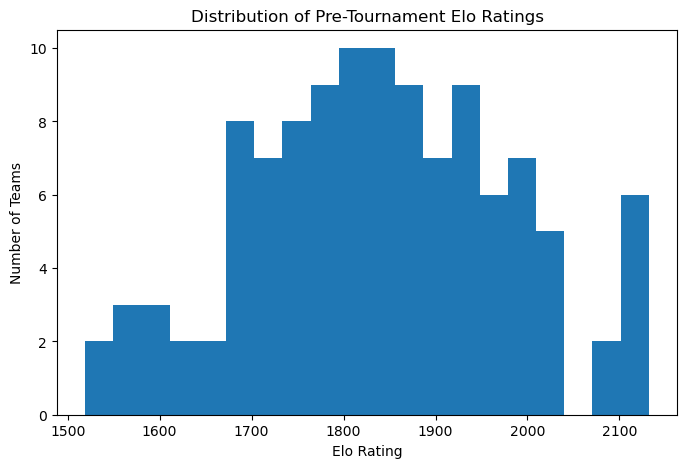

In [64]:
import matplotlib.pyplot as plt

elo_pd = (
    train_df
    .select("rating")
    .toPandas()
)

plt.figure(figsize=(8,5))
plt.hist(elo_pd["rating"].dropna(), bins=20)

plt.title("Distribution of Pre-Tournament Elo Ratings")
plt.xlabel("Elo Rating")
plt.ylabel("Number of Teams")

plt.savefig("elo_rating_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

The Elo ratings are approximately bell-shaped with a slight concentration near
the upper end. Missing values correspond to teams without historical Elo data
and will be median-imputed during preprocessing.

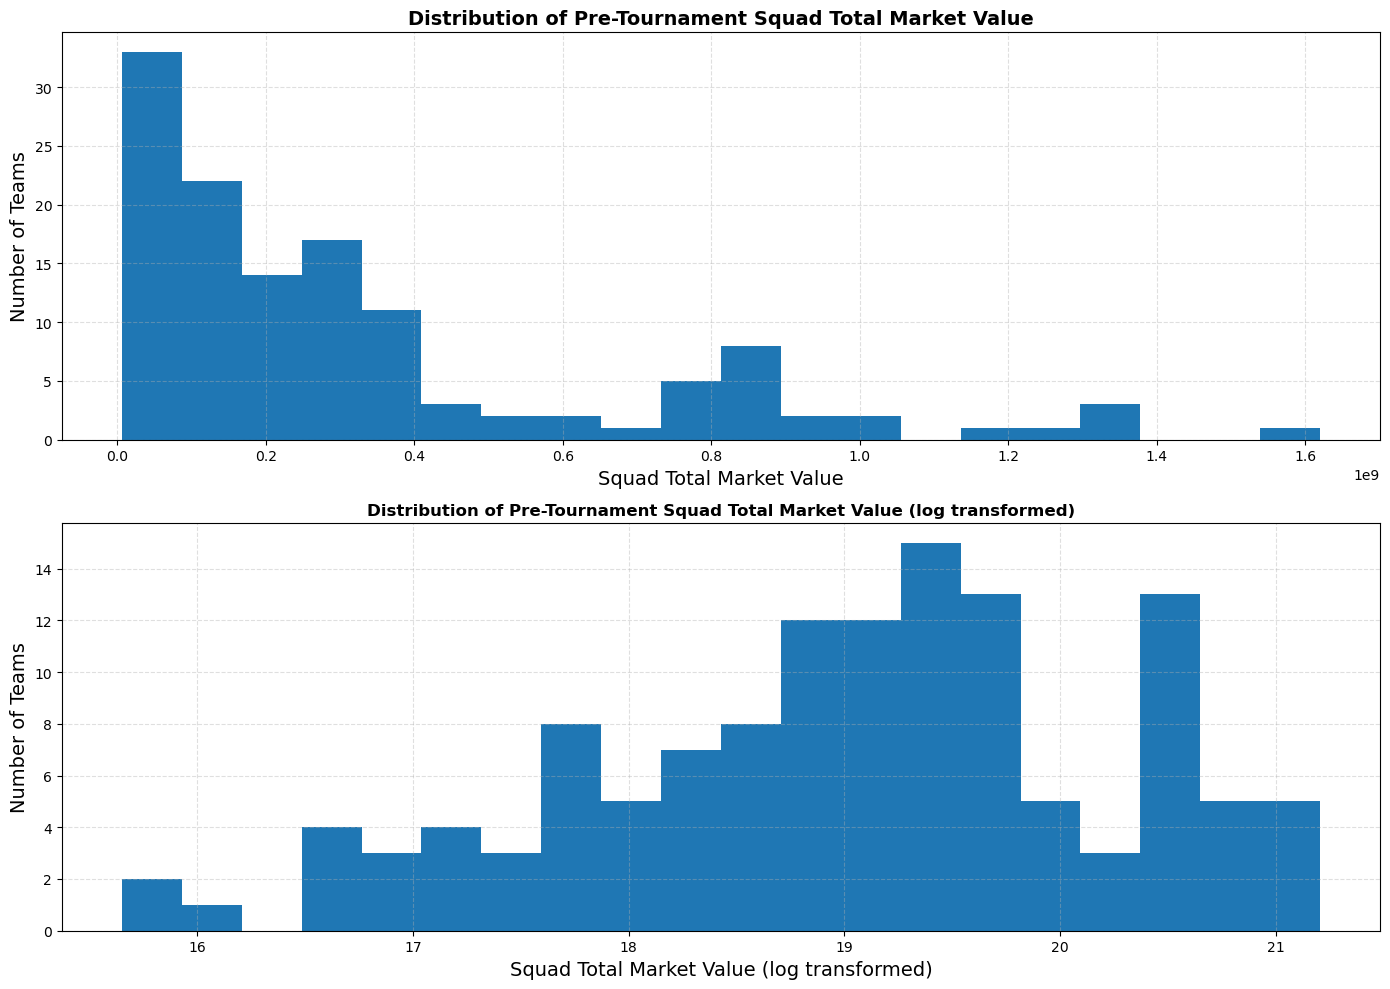

In [66]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import col, log1p
from pyspark.sql import functions as f
import numpy as np

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

squad_pd = (
    train_df
    .select("squad_total_market_value_eur")
    .toPandas()
)

squad_pd['log_squad_total_market_value_eur'] = np.log1p(squad_pd['squad_total_market_value_eur'])

train_df = train_df.withColumn(
    'log_squad_total_market_value_eur', 
    f.log1p('squad_total_market_value_eur')
)


ax1 = axes[0]
ax1.hist(squad_pd["squad_total_market_value_eur"].dropna(), bins=20)
ax1.set_title("Distribution of Pre-Tournament Squad Total Market Value", fontsize=14, fontweight="bold")
ax1.set_xlabel("Squad Total Market Value", fontsize=14)
ax1.set_ylabel("Number of Teams", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.4, zorder=1)

ax2 = axes[1]
ax2.hist(squad_pd["log_squad_total_market_value_eur"].dropna(), bins=20)
ax2.set_title("Distribution of Pre-Tournament Squad Total Market Value (log transformed)", fontsize=12, fontweight="bold")
ax2.set_xlabel("Squad Total Market Value (log transformed)", fontsize=14)
ax2.set_ylabel("Number of Teams", fontsize=14)
ax2.grid(True, linestyle="--", alpha=0.4, zorder=1)


plt.tight_layout()
plt.savefig(
    "squad_market_value_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

 The squad total market value is highly right skewed likely because it is a monetary value which tends to have right skewed distributions. After a log transformation, this value has a much more balanced distribution and makes it a better candidate for using a median-imputed value to replace missing values.

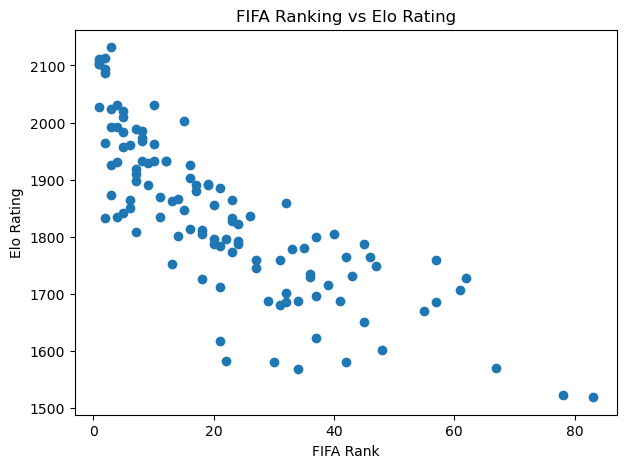

In [67]:
scatter_pd = (
    train_df.select(
        "fifa_rank_pre_tournament",
        "rating"
    )
    .toPandas()
)

plt.figure(figsize=(7,5))

plt.scatter(
    scatter_pd["fifa_rank_pre_tournament"],
    scatter_pd["rating"]
)

plt.xlabel("FIFA Rank")
plt.ylabel("Elo Rating")
plt.title("FIFA Ranking vs Elo Rating")

plt.savefig(
    "fifa_rank_vs_elo_rating.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The scatter plot shows a strong inverse relationship between FIFA ranking and Elo rating. Teams with better FIFA rankings (lower numerical rank) generally have higher Elo ratings, while lower-ranked teams tend to have lower Elo ratings. Although these variables measure similar aspects of team quality, the relationship is not perfectly linear, indicating that each may provide unique information to the machine learning models.

<Figure size 700x500 with 0 Axes>

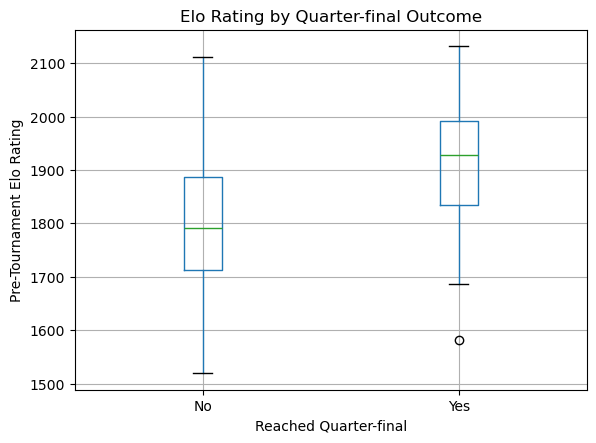

In [68]:
boxplot_pd = (
    train_df.select("rating", "quarter_finalist")
    .toPandas()
)

plt.figure(figsize=(7,5))

boxplot_pd.boxplot(
    column="rating",
    by="quarter_finalist"
)

plt.title("Elo Rating by Quarter-final Outcome")
plt.suptitle("")
plt.xticks([1, 2], ["No", "Yes"])
plt.xlabel("Reached Quarter-final")
plt.ylabel("Pre-Tournament Elo Rating")

plt.savefig(
    "elo_rating_by_quarter_final_outcome.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The boxplot indicates that teams reaching the quarter-finals generally entered the tournament with higher pre-tournament Elo ratings than teams eliminated earlier. Quarter-finalists have a noticeably higher median Elo rating and a higher overall distribution, suggesting that stronger teams are more likely to advance to the later stages of the tournament.

There is still substantial overlap between the two groups, however, indicating that Elo rating alone cannot perfectly predict tournament success. The presence of overlap and a few lower-rated quarter-finalists demonstrates that factors beyond pre-tournament team strength also influence World Cup outcomes. These observations support using Elo rating as an important predictor while reinforcing the need for multivariate machine learning models that combine several features.

In [69]:
numeric_pd = (
    train_df.select(
        "goals_scored_last_4y",
        "goals_received_last_4y",
        "wins_last_4y",
        "losses_last_4y",
        "draws_last_4y",
        "fifa_rank_pre_tournament",
        "rating",
        "squad_total_market_value_eur"
    ).toPandas()
)

numeric_pd.corr(numeric_only=True)

,goals_scored_last_4y,goals_received_last_4y,wins_last_4y,losses_last_4y,draws_last_4y,fifa_rank_pre_tournament,rating,squad_total_market_value_eur
goals_scored_last_4y,1.000000,0.316039,0.869244,0.042367,0.013629,-0.276489,0.415195,0.267467
goals_received_last_4y,0.316039,1.000000,0.194060,0.840462,0.240474,0.221206,-0.292387,-0.366372
wins_last_4y,0.869244,0.194060,1.000000,-0.008834,-0.033982,-0.326728,0.363308,0.306548
losses_last_4y,0.042367,0.840462,-0.008834,1.000000,0.165269,0.432721,-0.570268,-0.509739
draws_last_4y,0.013629,0.240474,-0.033982,0.165269,1.000000,0.155703,-0.212086,-0.162614
fifa_rank_pre_tournament,-0.276489,0.221206,-0.326728,0.432721,0.155703,1.000000,-0.799471,-0.551513
rating,0.415195,-0.292387,0.363308,-0.570268,-0.212086,-0.799471,1.000000,0.671987
squad_total_market_value_eur,0.267467,-0.366372,0.306548,-0.509739,-0.162614,-0.551513,0.671987,1.000000


The correlation analysis shows several expected relationships among the predictor variables. Goals scored and wins over the previous four years exhibit a strong positive correlation (0.87), indicating that teams with stronger recent offensive performance generally accumulated more victories. Conversely, goals conceded are strongly positively correlated with losses (0.84), suggesting that weaker defensive performance is associated with poorer match outcomes.

Pre-tournament FIFA ranking and Elo rating have a strong negative correlation (-0.80). Since lower FIFA rankings indicate stronger teams while higher Elo ratings also represent stronger teams, this inverse relationship is expected. However, the correlation is not perfect, suggesting that the two metrics capture slightly different aspects of team quality and may each contribute useful information to the predictive models.

Squad market value shows a moderately strong positive correlation with Elo rating (0.67) and a moderate negative correlation with FIFA ranking (-0.55). This suggests that more valuable squads tend to be stronger teams, although market value alone is not a complete measure of team performance.

Overall, no pair of variables exhibits near-perfect correlation, so all selected predictors will be retained for modeling. Tree-based models are generally robust to correlated features, while the logistic regression benchmark will benefit from feature scaling within the Spark ML pipeline.

### Multivariate graphs

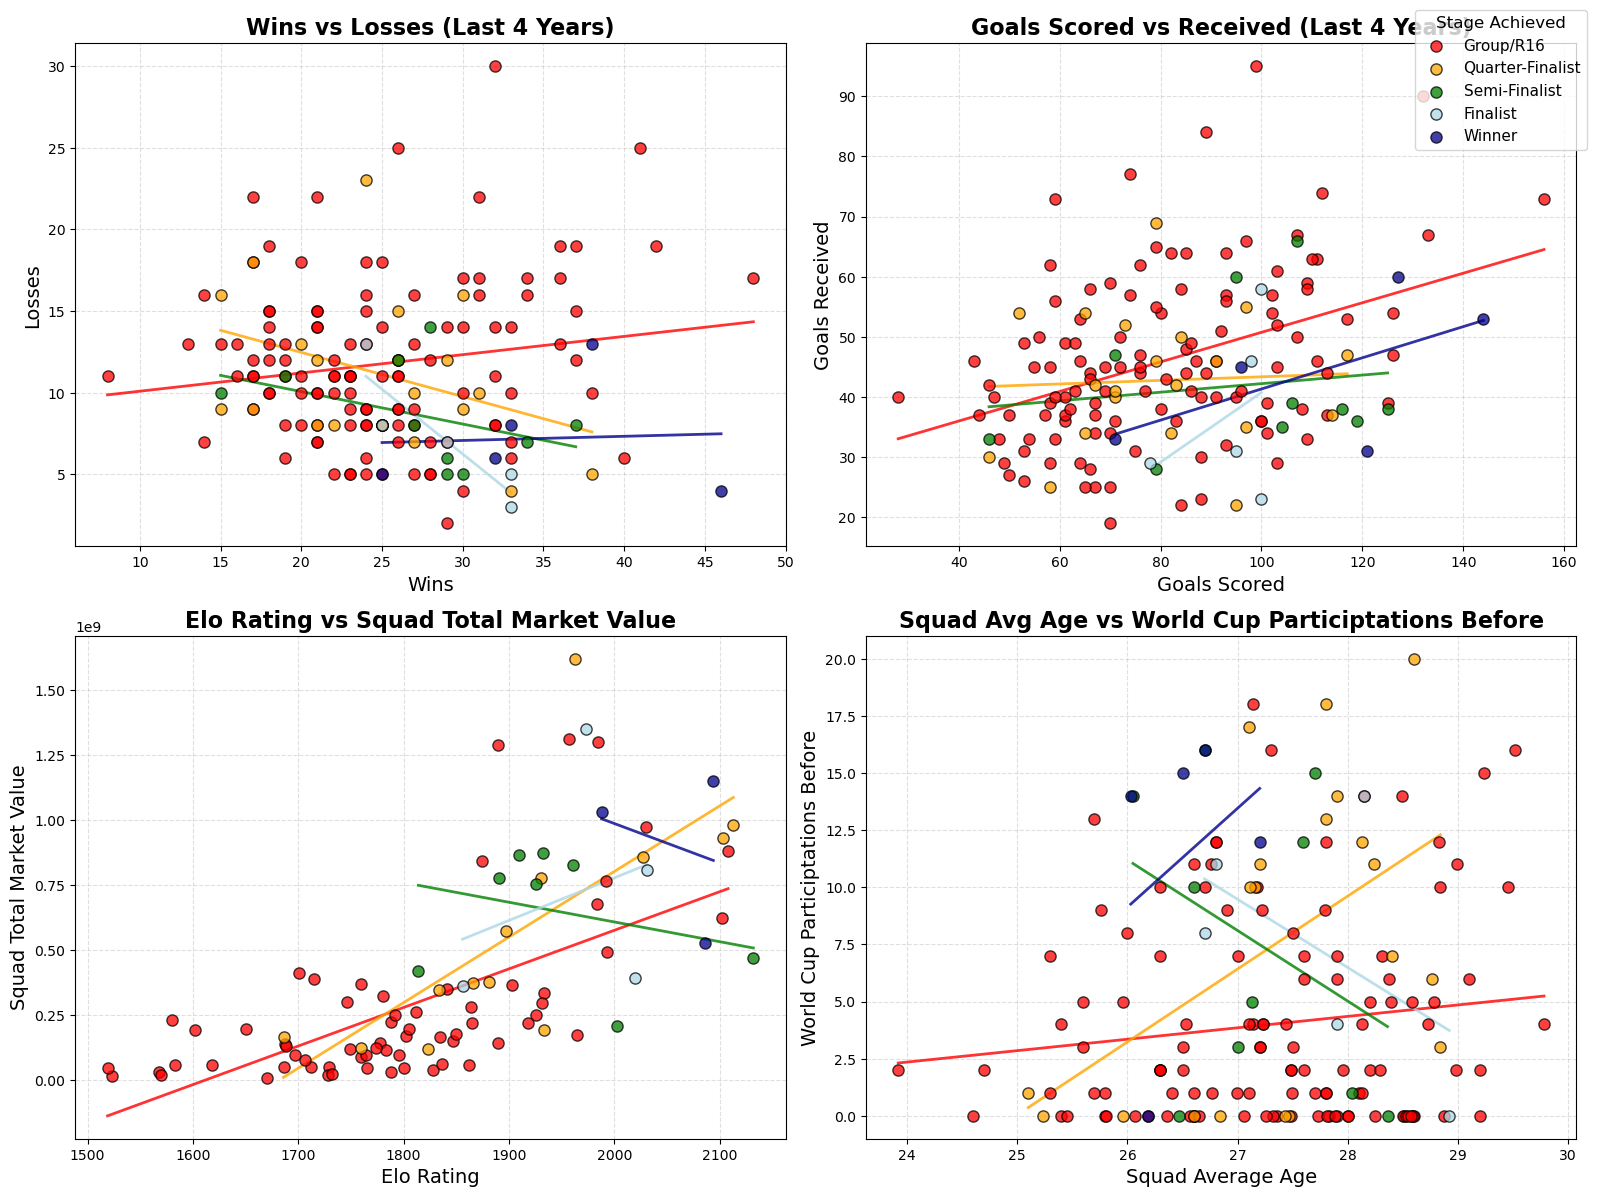

In [70]:
import numpy as np
stage_colors = {
    "Group/R16": "Red",
    "Quarter-Finalist": "Orange",
    "Semi-Finalist": "Green",
    "Finalist": "LightBlue",
    "Winner": "DarkBlue"
}

stage_order = ["Group/R16", "Quarter-Finalist", "Semi-Finalist", "Finalist", "Winner"]

num_features = [
    "goals_scored_last_4y", "goals_received_last_4y", "wins_last_4y", 
    "losses_last_4y", "draws_last_4y", "world_cup_titles_before",  "fifa_rank_pre_tournament", 
    "fifa_points_pre_tournament", "squad_avg_age", "world_cup_participations_before", 
    "groups_passed_before", "round16_before", "quarterfinals_before", 
    "semifinals_before", "finals_before", "rating_max", "rating_avg", 
    "rating_min", "rating", "squad_total_market_value_eur"
]

filled_df = train_df.na.fill(value=0, subset=["winner", "finalist", "semi_finalist", "quarter_finalist"]).withColumn(
    "max_stage_achieved",
    F.when(F.col("winner") == 1, "Winner")
     .when(F.col("finalist") == 1, "Finalist")
     .when(F.col("semi_finalist") == 1, "Semi-Finalist")
     .when(F.col("quarter_finalist") == 1, "Quarter-Finalist")
     .otherwise("Group/R16")
)


pdf = filled_df.select(num_features + ["max_stage_achieved"]).toPandas()


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

legend_handles = []
legend_labels = []

# Wins vs Losses (Last 4 Years)
ax1 = axes[0, 0]
for stage in stage_order:
    stage_data = pdf[pdf["max_stage_achieved"] == stage].dropna(subset=["wins_last_4y", "losses_last_4y"])
    x1, y1 = stage_data["wins_last_4y"].values, stage_data["losses_last_4y"].values
    if len(x1) < 2: continue
    
    sc = ax1.scatter(x1, y1, color=stage_colors[stage], edgecolor="black", s=65, alpha=0.75, zorder=3)
    
    if stage not in legend_labels:
        legend_handles.append(sc)
        legend_labels.append(stage)
        
    slope, intercept = np.polyfit(x1, y1, 1)
    x1_range = np.linspace(x1.min(), x1.max(), 100)
    ax1.plot(x1_range, slope * x1_range + intercept, color=stage_colors[stage], linewidth=2, alpha=0.8, zorder=2)

ax1.set_title("Wins vs Losses (Last 4 Years)", fontsize=16, fontweight="bold")
ax1.set_xlabel("Wins", fontsize=14)
ax1.set_ylabel("Losses", fontsize=14)
ax1.grid(True, linestyle="--", alpha=0.4, zorder=1)

# Goals Scored vs Goals Received (Last 4 Years)
ax2 = axes[0, 1]
for stage in stage_order:
    stage_data = pdf[pdf["max_stage_achieved"] == stage].dropna(subset=["goals_scored_last_4y", "goals_received_last_4y"])
    x2, y2 = stage_data["goals_scored_last_4y"].values, stage_data["goals_received_last_4y"].values
    if len(x2) < 2: continue
    
    ax2.scatter(x2, y2, color=stage_colors[stage], edgecolor="black", s=65, alpha=0.75, zorder=3)
    
    slope, intercept = np.polyfit(x2, y2, 1)
    x2_range = np.linspace(x2.min(), x2.max(), 100)
    ax2.plot(x2_range, slope * x2_range + intercept, color=stage_colors[stage], linewidth=2, alpha=0.8, zorder=2)

ax2.set_title("Goals Scored vs Received (Last 4 Years)", fontsize=16, fontweight="bold")
ax2.set_xlabel("Goals Scored", fontsize=14)
ax2.set_ylabel("Goals Received", fontsize=14)
ax2.grid(True, linestyle="--", alpha=0.4, zorder=1)

# Elo Rating vs Squad total market value
ax3 = axes[1, 0]
for stage in stage_order:
    stage_data = pdf[pdf["max_stage_achieved"] == stage].dropna(subset=["rating", "squad_total_market_value_eur"])
    x3, y3 = stage_data["rating"].values, stage_data["squad_total_market_value_eur"].values
    if len(x3) < 2: continue
    
    ax3.scatter(x3, y3, color=stage_colors[stage], edgecolor="black", s=65, alpha=0.75, zorder=3)
    
    slope, intercept = np.polyfit(x3, y3, 1)
    x3_range = np.linspace(x3.min(), x3.max(), 100)
    ax3.plot(x3_range, slope * x3_range + intercept, color=stage_colors[stage], linewidth=2, alpha=0.8, zorder=2)

ax3.set_title("Elo Rating vs Squad Total Market Value", fontsize=16, fontweight="bold")
ax3.set_xlabel("Elo Rating", fontsize=14)
ax3.set_ylabel("Squad Total Market Value", fontsize=14)
ax3.grid(True, linestyle="--", alpha=0.4, zorder=1)

# Squad Average Age vs World Cup Participtations Before
ax4 = axes[1, 1]
for stage in stage_order:
    stage_data = pdf[pdf["max_stage_achieved"] == stage].dropna(subset=["squad_avg_age", "world_cup_participations_before"])
    x4, y4 = stage_data["squad_avg_age"].values, stage_data["world_cup_participations_before"].values
    if len(x4) < 2: continue
    
    ax4.scatter(x4, y4, color=stage_colors[stage], edgecolor="black", s=65, alpha=0.75, zorder=3)
    
    slope, intercept = np.polyfit(x4, y4, 1)
    x4_range = np.linspace(x4.min(), x4.max(), 100)
    ax4.plot(x4_range, slope * x4_range + intercept, color=stage_colors[stage], linewidth=2, alpha=0.8, zorder=2)

ax4.set_title("Squad Avg Age vs World Cup Participtations Before", fontsize=16, fontweight="bold")
ax4.set_xlabel("Squad Average Age", fontsize=14)
ax4.set_ylabel("World Cup Participtations Before", fontsize=14)
ax4.grid(True, linestyle="--", alpha=0.4, zorder=1)


fig.legend(
    handles=legend_handles, 
    labels=legend_labels, 
    title="Stage Achieved", 
    loc="upper right", 
    bbox_to_anchor=(1, 1), 
    frameon=True,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.savefig(
    "feature_relationships_by_tournament_stage.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

The plots above consist of several multivariate plots of continuous variables colored by the max stage of the team reach with a regression line for interpretability. The first plot includes a Wins Vs Loss in the last 4 Years (before each world cup). Intuitively it makes sense that a team with more wins than losses will do better in the tournament and this is reflected by the regression lines with a negative slope or shifted down (less losses. Interestingly, it seems that the take away from this graph was that outcome is more determined by ratio of wins to losses than by per losses reflecting experience teams get by playing games in the build up to the world cup. The second plot includes Goals Scored vs Goals Received in the last 4 Years (before each world cup). This plot shows a very strong positive relationship between Goals Scored and Goals Received with positive slopes for all the regression lines at each stage. However, the differentiator of higher levels of success seems to be goals received reflected by lower intercepts of winners vs group stage on the Goals Received axis. This suggests defensive capabilities are a potentially more important aspect of winning the world cup than offense. The third plot is of Elo Rating vs Squad Total Market Value, which does show a lot of separation between teams success at the tournament and the squad value / elo. Interestingly, despite their elo ranking, teams in the Round of 16 stage have a similar squad total market value whereas teams with higher squad values have generally higher elo rankings and more success in the tournament. The forth plot Squad Avg Age vs World Cup Participations Before. This plot indicates that world cup participation seems to be more important than squad age but also shows a relationship between successful teams having more participation and higher squad age. This is a reflection on experience and prior results of the team being more important than player experience at world cups.

## 7. Spark ML Preprocessing Pipeline

This section builds reusable preprocessing pipelines for all machine learning
models.

The pipelines perform:

- median imputation of missing numeric values
- categorical encoding
- feature vector assembly
- feature scaling (logistic regression only)

The same preprocessing steps are applied consistently to the training,
testing, and 2026 prediction datasets.

In [71]:
from pyspark.ml import Pipeline

from pyspark.ml.feature import (
    Imputer,
    StringIndexer,
    OneHotEncoder,
    VectorAssembler,
    StandardScaler
)

In [72]:
numeric_features = [

    "goals_scored_last_4y",
    "goals_received_last_4y",

    "wins_last_4y",
    "losses_last_4y",
    "draws_last_4y",

    "world_cup_titles_before",

    "squad_total_market_value_eur",
    "market_value_missing",

    "fifa_rank_pre_tournament",
    "fifa_points_pre_tournament",

    "squad_avg_age",

    "world_cup_participations_before",
    "groups_passed_before",
    "round16_before",
    "quarterfinals_before",
    "semifinals_before",
    "finals_before",

    "rating",
    "rating_avg",
    "rating_max",
    "rating_min",

    "elo_missing"
]

In [73]:
imputer = Imputer(
    inputCols=numeric_features,
    outputCols=[f"{c}_imp" for c in numeric_features],
    strategy="median"
)

In [74]:
continent_indexer = StringIndexer(
    inputCol="continent",
    outputCol="continent_index",
    handleInvalid="keep"
)

continent_encoder = OneHotEncoder(
    inputCols=["continent_index"],
    outputCols=["continent_vector"]
)

In [75]:
assembled_features = [
    f"{c}_imp"
    for c in numeric_features
] + ["continent_vector"]

assembler = VectorAssembler(
    inputCols=assembled_features,
    outputCol="features_raw"
)

In [76]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withStd=True,
    withMean=False
)

In [77]:
lr_preprocessing_pipeline = Pipeline(
    stages=[
        imputer,
        continent_indexer,
        continent_encoder,
        assembler,
        scaler
    ]
)

In [78]:
tree_preprocessing_pipeline = Pipeline(
    stages=[
        imputer,
        continent_indexer,
        continent_encoder,
        assembler
    ]
)

In [79]:
lr_preprocessor = lr_preprocessing_pipeline.fit(train_df)

tree_preprocessor = tree_preprocessing_pipeline.fit(train_df)

In [80]:
train_lr = lr_preprocessor.transform(train_df)

test_lr = lr_preprocessor.transform(test_df)

prediction_lr = lr_preprocessor.transform(prediction_2026_df)

In [81]:
train_tree = tree_preprocessor.transform(train_df)

test_tree = tree_preprocessor.transform(test_df)

prediction_tree = tree_preprocessor.transform(prediction_2026_df)

In [82]:
train_lr.select(
    "features"
).show(5, truncate=False)

+----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|features                                                                                                                                                                                                                                                                                                                                                                                                                          |
+-------------------------------------------------------------------------------------------------------------------------------------------------------------

In [83]:
train_tree.select(
    "features_raw"
).show(5, truncate=False)

+--------------------------------------------------------------------------------------------------------------------------------------------+
|features_raw                                                                                                                                |
+--------------------------------------------------------------------------------------------------------------------------------------------+
|(28,[0,1,2,3,4,6,8,9,10,17,18,19,20,21,23],[61.0,49.0,19.0,13.0,14.0,5.27E7,57.0,581.0,29.2,1834.0,1747.0,1958.0,1503.0,1.0,1.0])           |
|[97.0,55.0,31.0,10.0,10.0,2.0,7.772E8,0.0,9.0,746.0,27.8,13.0,10.0,5.0,6.0,4.0,4.0,1930.0,1981.0,2159.0,1751.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0] |
|(28,[0,1,2,3,4,6,8,9,10,11,17,18,19,20,27],[101.0,34.0,23.0,8.0,5.0,4.803E7,42.0,612.0,27.1,1.0,1765.0,1654.0,1876.0,1475.0,1.0])           |
|[117.0,47.0,30.0,9.0,17.0,5.0,8.585E8,0.0,1.0,827.0,27.1,17.0,15.0,7.0,11.0,9.0,6.0,2027.0,1981.0,2195.0,1805.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0]|

In [84]:
print("Training rows:", train_lr.count())
print("Testing rows:", test_lr.count())
print("Prediction rows:", prediction_lr.count())

Training rows: 160
Testing rows: 32
Prediction rows: 48


## 8. Logistic Regression Benchmark

A separate logistic regression model is trained for each tournament milestone:

- Quarter-final
- Semi-final
- Final
- Winner

These models serve as benchmark classifiers against which the Random Forest and
Gradient Boosted Tree models will be compared.

In [85]:
from pyspark.ml.classification import LogisticRegression

from pyspark.ml.evaluation import BinaryClassificationEvaluator

from pyspark.ml.tuning import (
    ParamGridBuilder,
    CrossValidator
)

In [86]:
def fit_logistic_regression(train_data, label):

    lr = LogisticRegression(
        featuresCol="features",
        labelCol=label,
        maxIter=100,
        regParam=0.01,
        elasticNetParam=0.0
    )

    param_grid = (
        ParamGridBuilder()
        .addGrid(lr.regParam, [0.001, 0.01, 0.1])
        .addGrid(lr.elasticNetParam, [0.0, 0.5])
        .build()
    )

    evaluator = BinaryClassificationEvaluator(
        labelCol=label,
        metricName="areaUnderROC"
    )

    cv = CrossValidator(
        estimator=lr,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=3,
        seed=5110
    )

    model = cv.fit(train_data)

    return model

In [87]:
lr_models = {}

for target in target_columns:

    print(f"Training {target}...")

    lr_models[target] = fit_logistic_regression(
        train_lr,
        target
    )

Training quarter_finalist...


26/07/23 11:26:33 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


Training semi_finalist...
Training finalist...
Training winner...


## 9. Logistic Regression Evaluation

The four logistic regression benchmark models are evaluated on the held-out
2022 World Cup test set.

For each target, we report:

- accuracy
- precision
- recall
- F1 score
- area under the ROC curve
- confusion matrix

Because the milestone outcomes are imbalanced, accuracy is interpreted together
with precision, recall, F1, and AUROC.

In [88]:
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)

In [89]:
def evaluate_binary_model(
    predictions,
    label_col,
    model_name
):
    """
    Evaluate a binary Spark ML classifier.

    Parameters
    ----------
    predictions : pyspark.sql.DataFrame
        Dataframe containing label, prediction, and rawPrediction columns.
    label_col : str
        Name of the binary target column.
    model_name : str
        Model name used in the output table.

    Returns
    -------
    dict
        Classification metrics and confusion-matrix counts.
    """

    # AUROC uses the raw prediction scores.
    auc_evaluator = BinaryClassificationEvaluator(
        labelCol=label_col,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    # Spark's multiclass evaluator also supports binary classification metrics.
    accuracy_evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="accuracy"
    )

    precision_evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedPrecision"
    )

    recall_evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="weightedRecall"
    )

    f1_evaluator = MulticlassClassificationEvaluator(
        labelCol=label_col,
        predictionCol="prediction",
        metricName="f1"
    )

    # Confusion-matrix counts.
    counts = (
        predictions
        .select(
            F.col(label_col).cast("integer").alias("label"),
            F.col("prediction").cast("integer").alias("prediction")
        )
        .groupBy("label", "prediction")
        .count()
        .collect()
    )

    confusion = {
        (row["label"], row["prediction"]): row["count"]
        for row in counts
    }

    tn = confusion.get((0, 0), 0)
    fp = confusion.get((0, 1), 0)
    fn = confusion.get((1, 0), 0)
    tp = confusion.get((1, 1), 0)

    return {
        "model": model_name,
        "target": label_col,
        "accuracy": accuracy_evaluator.evaluate(predictions),
        "precision": precision_evaluator.evaluate(predictions),
        "recall": recall_evaluator.evaluate(predictions),
        "f1": f1_evaluator.evaluate(predictions),
        "auroc": auc_evaluator.evaluate(predictions),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

In [90]:
def add_positive_class_metrics(result):
    """
    Add positive-class precision, recall, and F1 to a metrics dictionary.
    """

    tp = result["tp"]
    fp = result["fp"]
    fn = result["fn"]

    positive_precision = (
        tp / (tp + fp)
        if (tp + fp) > 0
        else 0.0
    )

    positive_recall = (
        tp / (tp + fn)
        if (tp + fn) > 0
        else 0.0
    )

    positive_f1 = (
        2 * positive_precision * positive_recall
        / (positive_precision + positive_recall)
        if (positive_precision + positive_recall) > 0
        else 0.0
    )

    result["positive_precision"] = positive_precision
    result["positive_recall"] = positive_recall
    result["positive_f1"] = positive_f1

    return result

In [91]:
lr_test_predictions = {}

for target in target_columns:
    lr_test_predictions[target] = (
        lr_models[target]
        .transform(test_lr)
    )

In [92]:
from pyspark.ml.functions import vector_to_array

(
    lr_test_predictions["quarter_finalist"]
    .withColumn(
        "positive_probability",
        vector_to_array("probability")[1]
    )
    .select(
        "team",
        "quarter_finalist",
        "positive_probability",
        "prediction"
    )
    .orderBy(F.desc("positive_probability"))
    .show(32, truncate=False)
)

+-------------+----------------+--------------------+----------+
|team         |quarter_finalist|positive_probability|prediction|
+-------------+----------------+--------------------+----------+
|Brazil       |1               |0.8863157329892106  |1.0       |
|Germany      |0               |0.8250661838556209  |1.0       |
|Argentina    |1               |0.7385431579896153  |1.0       |
|England      |1               |0.7252505946891787  |1.0       |
|Spain        |0               |0.6977320450288085  |1.0       |
|France       |1               |0.6548063869015626  |1.0       |
|Uruguay      |0               |0.5146231712769439  |1.0       |
|Netherlands  |1               |0.4916716227817254  |0.0       |
|Portugal     |1               |0.4862590196783765  |0.0       |
|Belgium      |0               |0.3553228911567923  |0.0       |
|Croatia      |1               |0.32448042408679034 |0.0       |
|Ecuador      |0               |0.2701990921299089  |0.0       |
|Switzerland  |0         

In [93]:
lr_results = []

for target in target_columns:
    result = evaluate_binary_model(
        predictions=lr_test_predictions[target],
        label_col=target,
        model_name="Logistic Regression"
    )

    result = add_positive_class_metrics(result)

    lr_results.append(result)

In [94]:
lr_results_df = spark.createDataFrame(lr_results)

lr_results_df.select(
    "model",
    "target",
    F.round("accuracy", 3).alias("accuracy"),
    F.round("positive_precision", 3).alias("precision"),
    F.round("positive_recall", 3).alias("recall"),
    F.round("positive_f1", 3).alias("f1"),
    F.round("auroc", 3).alias("auroc"),
    "tn",
    "fp",
    "fn",
    "tp"
).orderBy("target").show(truncate=False)

[Stage 6758:>                                                       (0 + 4) / 4]

+-------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|model              |target          |accuracy|precision|recall|f1   |auroc|tn |fp |fn |tp |
+-------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|Logistic Regression|finalist        |0.938   |0.0      |0.0   |0.0  |0.867|30 |0  |2  |0  |
|Logistic Regression|quarter_finalist|0.781   |0.571    |0.5   |0.533|0.87 |21 |3  |4  |4  |
|Logistic Regression|semi_finalist   |0.781   |0.2      |0.25  |0.222|0.723|24 |4  |3  |1  |
|Logistic Regression|winner          |0.969   |0.0      |0.0   |0.0  |0.806|31 |0  |1  |0  |
+-------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+



In [95]:
confusion_rows = []

for result in lr_results:
    confusion_rows.extend([
        {
            "target": result["target"],
            "actual": 0,
            "predicted_0": result["tn"],
            "predicted_1": result["fp"]
        },
        {
            "target": result["target"],
            "actual": 1,
            "predicted_0": result["fn"],
            "predicted_1": result["tp"]
        }
    ])

spark.createDataFrame(confusion_rows).orderBy(
    "target",
    "actual"
).show(truncate=False)

+------+-----------+-----------+----------------+
|actual|predicted_0|predicted_1|target          |
+------+-----------+-----------+----------------+
|0     |30         |0          |finalist        |
|1     |2          |0          |finalist        |
|0     |21         |3          |quarter_finalist|
|1     |4          |4          |quarter_finalist|
|0     |24         |4          |semi_finalist   |
|1     |3          |1          |semi_finalist   |
|0     |31         |0          |winner          |
|1     |1          |0          |winner          |
+------+-----------+-----------+----------------+



In [96]:
lr_best_params = []

for target in target_columns:
    best_lr = lr_models[target].bestModel

    lr_best_params.append({
        "target": target,
        "regParam": float(best_lr.getRegParam()),
        "elasticNetParam": float(best_lr.getElasticNetParam()),
        "maxIter": int(best_lr.getMaxIter())
    })

spark.createDataFrame(lr_best_params).show(truncate=False)

+---------------+-------+--------+----------------+
|elasticNetParam|maxIter|regParam|target          |
+---------------+-------+--------+----------------+
|0.0            |100    |0.1     |quarter_finalist|
|0.0            |100    |0.1     |semi_finalist   |
|0.5            |100    |0.1     |finalist        |
|0.0            |100    |0.1     |winner          |
+---------------+-------+--------+----------------+



In [97]:
naive_results = []

for target in target_columns:
    total = test_df.count()
    negatives = test_df.filter(F.col(target) == 0).count()

    naive_results.append({
        "target": target,
        "always_negative_accuracy": negatives / total
    })

spark.createDataFrame(naive_results).show(truncate=False)

+------------------------+----------------+
|always_negative_accuracy|target          |
+------------------------+----------------+
|0.75                    |quarter_finalist|
|0.875                   |semi_finalist   |
|0.9375                  |finalist        |
|0.96875                 |winner          |
+------------------------+----------------+



### Logistic Regression Benchmark Results

The logistic regression benchmark performed reasonably well for predicting
quarter-finalists, achieving an AUROC of 0.87 and an F1 score of 0.53 on the
held-out 2022 World Cup. The model correctly identified four of the eight
quarter-finalists while maintaining relatively few false positives.

Performance declined as the prediction task became more difficult. For the
semi-final prediction, the model identified only one of four true
semi-finalists, resulting in an F1 score of 0.22. For the finalist and winner
models, no positive predictions were made at the default probability threshold
of 0.5, producing precision, recall, and F1 scores of zero despite relatively
high AUROC values.

These results reflect the severe class imbalance in the historical training
data, where only ten finalists and five champions were available for training.
Although logistic regression provides a useful baseline, more flexible
tree-based models are expected to better capture the nonlinear relationships
between team strength and tournament advancement.

## 10. Random Forest Models

Random Forest classifiers are trained separately for each tournament milestone.

Random Forest can capture nonlinear relationships and interactions among team
strength, recent performance, tournament history, market value, and Elo-based
features. Hyperparameters are selected using cross-validation on the training
data only.

In [98]:
from pyspark.ml.classification import RandomForestClassifier

def fit_random_forest(train_data, label):
    """
    Fit a cross-validated Random Forest classifier for one binary target.
    """

    rf = RandomForestClassifier(
        featuresCol="features_raw",
        labelCol=label,
        seed=5110
    )

    param_grid = (
        ParamGridBuilder()
        .addGrid(rf.numTrees, [50, 100])
        .addGrid(rf.maxDepth, [3, 5])
        .addGrid(rf.minInstancesPerNode, [1, 3])
        .build()
    )

    evaluator = BinaryClassificationEvaluator(
        labelCol=label,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    cv = CrossValidator(
        estimator=rf,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=3,
        seed=5110,
        parallelism=2
    )

    return cv.fit(train_data)

In [99]:
rf_models = {}

for target in target_columns:
    print(f"Training Random Forest for {target}...")

    rf_models[target] = fit_random_forest(
        train_tree,
        target
    )

Training Random Forest for quarter_finalist...
Training Random Forest for semi_finalist...


26/07/23 11:29:20 WARN BlockManager: Block rdd_13187_0 already exists on this machine; not re-adding it


Training Random Forest for finalist...


26/07/23 11:29:32 WARN BlockManager: Block rdd_15212_0 already exists on this machine; not re-adding it


Training Random Forest for winner...


26/07/23 11:29:43 WARN BlockManager: Block rdd_17237_0 already exists on this machine; not re-adding it
26/07/23 11:29:44 WARN BlockManager: Block rdd_17362_0 already exists on this machine; not re-adding it
26/07/23 11:29:47 WARN BlockManager: Block rdd_17887_0 already exists on this machine; not re-adding it
26/07/23 11:29:50 WARN BlockManager: Block rdd_18534_0 already exists on this machine; not re-adding it


In [100]:
rf_test_predictions = {}

for target in target_columns:
    rf_test_predictions[target] = (
        rf_models[target]
        .transform(test_tree)
    )

In [101]:
(
    rf_test_predictions["quarter_finalist"]
    .withColumn(
        "positive_probability",
        vector_to_array("probability")[1]
    )
    .select(
        "team",
        "quarter_finalist",
        "positive_probability",
        "prediction"
    )
    .orderBy(F.desc("positive_probability"))
    .show(32, truncate=False)
)

+-------------+----------------+--------------------+----------+
|team         |quarter_finalist|positive_probability|prediction|
+-------------+----------------+--------------------+----------+
|Brazil       |1               |0.7593329916201522  |1.0       |
|Argentina    |1               |0.7453663426815814  |1.0       |
|England      |1               |0.6799526219067465  |1.0       |
|Netherlands  |1               |0.6718699241744266  |1.0       |
|France       |1               |0.6610704265078313  |1.0       |
|Spain        |0               |0.6485688289956956  |1.0       |
|Germany      |0               |0.5894956567430163  |1.0       |
|Uruguay      |0               |0.5883113107581982  |1.0       |
|Belgium      |0               |0.5747978157385983  |1.0       |
|Portugal     |1               |0.4229591326082124  |0.0       |
|Croatia      |1               |0.29982519069682984 |0.0       |
|Switzerland  |0               |0.2761565304453712  |0.0       |
|Mexico       |0         

In [102]:
rf_results = []

for target in target_columns:
    result = evaluate_binary_model(
        predictions=rf_test_predictions[target],
        label_col=target,
        model_name="Random Forest"
    )

    result = add_positive_class_metrics(result)

    rf_results.append(result)

In [103]:
rf_results_df = spark.createDataFrame(rf_results)

rf_results_df.select(
    "model",
    "target",
    F.round("accuracy", 3).alias("accuracy"),
    F.round("positive_precision", 3).alias("precision"),
    F.round("positive_recall", 3).alias("recall"),
    F.round("positive_f1", 3).alias("f1"),
    F.round("auroc", 3).alias("auroc"),
    "tn",
    "fp",
    "fn",
    "tp"
).orderBy("target").show(truncate=False)

+-------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|model        |target          |accuracy|precision|recall|f1   |auroc|tn |fp |fn |tp |
+-------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|Random Forest|finalist        |0.938   |0.0      |0.0   |0.0  |0.917|30 |0  |2  |0  |
|Random Forest|quarter_finalist|0.781   |0.556    |0.625 |0.588|0.906|20 |4  |3  |5  |
|Random Forest|semi_finalist   |0.75    |0.167    |0.25  |0.2  |0.768|23 |5  |3  |1  |
|Random Forest|winner          |0.969   |0.0      |0.0   |0.0  |0.806|31 |0  |1  |0  |
+-------------+----------------+--------+---------+------+-----+-----+---+---+---+---+



In [104]:
rf_best_params = []

for target in target_columns:
    best_rf = rf_models[target].bestModel

    num_trees = best_rf.getNumTrees

    if callable(num_trees):
        num_trees = num_trees()

    rf_best_params.append({
        "target": target,
        "numTrees": int(num_trees),
        "maxDepth": int(best_rf.getMaxDepth()),
        "minInstancesPerNode": int(
            best_rf.getMinInstancesPerNode()
        )
    })

spark.createDataFrame(rf_best_params).show(truncate=False)

+--------+-------------------+--------+----------------+
|maxDepth|minInstancesPerNode|numTrees|target          |
+--------+-------------------+--------+----------------+
|3       |1                  |100     |quarter_finalist|
|5       |1                  |100     |semi_finalist   |
|5       |3                  |50      |finalist        |
|3       |3                  |50      |winner          |
+--------+-------------------+--------+----------------+



In [105]:
lr_rf_results = lr_results + rf_results

lr_rf_results_df = spark.createDataFrame(lr_rf_results)

lr_rf_results_df.select(
    "model",
    "target",
    F.round("accuracy", 3).alias("accuracy"),
    F.round("positive_precision", 3).alias("precision"),
    F.round("positive_recall", 3).alias("recall"),
    F.round("positive_f1", 3).alias("f1"),
    F.round("auroc", 3).alias("auroc")
).orderBy(
    "target",
    F.desc("positive_f1")
).show(truncate=False)

+-------------------+----------------+--------+---------+------+-----+-----+
|model              |target          |accuracy|precision|recall|f1   |auroc|
+-------------------+----------------+--------+---------+------+-----+-----+
|Logistic Regression|finalist        |0.938   |0.0      |0.0   |0.0  |0.867|
|Random Forest      |finalist        |0.938   |0.0      |0.0   |0.0  |0.917|
|Random Forest      |quarter_finalist|0.781   |0.556    |0.625 |0.588|0.906|
|Logistic Regression|quarter_finalist|0.781   |0.571    |0.5   |0.533|0.87 |
|Logistic Regression|semi_finalist   |0.781   |0.2      |0.25  |0.222|0.723|
|Random Forest      |semi_finalist   |0.75    |0.167    |0.25  |0.2  |0.768|
|Random Forest      |winner          |0.969   |0.0      |0.0   |0.0  |0.806|
|Logistic Regression|winner          |0.969   |0.0      |0.0   |0.0  |0.806|
+-------------------+----------------+--------+---------+------+-----+-----+



In [106]:
best_rf_quarter = rf_models["quarter_finalist"].bestModel

feature_importance_values = (
    best_rf_quarter
    .featureImportances
    .toArray()
)

In [107]:
continent_model = tree_preprocessor.stages[1]
continent_labels = continent_model.labels

encoded_continent_names = [
    f"continent_{label}"
    for label in continent_labels
]

model_feature_names = (
    [f"{column}_imp" for column in numeric_features]
    + encoded_continent_names
)

In [108]:
print("Importance values:", len(feature_importance_values))
print("Feature names:", len(model_feature_names))

Importance values: 28
Feature names: 28


In [109]:
feature_importance_rows = [
    {
        "feature": name,
        "importance": float(importance)
    }
    for name, importance in zip(
        model_feature_names,
        feature_importance_values
    )
]

feature_importance_df = (
    spark.createDataFrame(feature_importance_rows)
    .orderBy(F.desc("importance"))
)

feature_importance_df.show(15, truncate=False)

+-----------------------------------+--------------------+
|feature                            |importance          |
+-----------------------------------+--------------------+
|rating_max_imp                     |0.13877723309445011 |
|rating_avg_imp                     |0.11196520535873697 |
|groups_passed_before_imp           |0.10529625427258205 |
|squad_total_market_value_eur_imp   |0.07678483063199042 |
|rating_min_imp                     |0.07581601721104997 |
|rating_imp                         |0.06176615818626366 |
|draws_last_4y_imp                  |0.04726425965521617 |
|squad_avg_age_imp                  |0.04486210469158474 |
|quarterfinals_before_imp           |0.03976576638712995 |
|round16_before_imp                 |0.039051401946001395|
|world_cup_participations_before_imp|0.03760258957731176 |
|goals_scored_last_4y_imp           |0.03350922258755052 |
|fifa_points_pre_tournament_imp     |0.029037888711958518|
|fifa_rank_pre_tournament_imp       |0.02359099638315045

### Random Forest Results

The Random Forest classifier outperformed the logistic regression benchmark for
predicting quarter-finalists. The model achieved an AUROC of 0.91 and improved
the F1 score from 0.53 to 0.59 by correctly identifying five of the eight
quarter-finalists in the 2022 World Cup.

Performance gains for the remaining targets were smaller because of the limited
number of positive training examples. Although the finalist and winner models
did not predict any positive cases at the default probability threshold, both
achieved relatively high AUROC values, suggesting that the models ranked the
strongest teams well despite the severe class imbalance.

Feature importance analysis indicates that historical Elo ratings and previous
World Cup performance were the strongest predictors of tournament advancement.
Squad market value also contributed meaningfully, while recent match statistics
and FIFA rankings had comparatively smaller influence.

## 11. Gradient Boosted Tree Models

Gradient Boosted Tree (GBT) classifiers are trained separately for each tournament
milestone.

Unlike Random Forest, GBT builds trees sequentially, allowing each tree to learn
from the errors of the previous trees. This often improves predictive
performance on structured datasets while requiring careful tuning to avoid
overfitting.

In [110]:
from pyspark.ml.classification import GBTClassifier

def fit_gbt(train_data, label):

    gbt = GBTClassifier(
        featuresCol="features_raw",
        labelCol=label,
        seed=5110
    )

    param_grid = (
        ParamGridBuilder()
        .addGrid(gbt.maxDepth, [3, 5])
        .addGrid(gbt.maxIter, [50, 100])
        .build()
    )

    evaluator = BinaryClassificationEvaluator(
        labelCol=label,
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )

    cv = CrossValidator(
        estimator=gbt,
        estimatorParamMaps=param_grid,
        evaluator=evaluator,
        numFolds=3,
        seed=5110,
        parallelism=2
    )

    return cv.fit(train_data)

In [111]:
gbt_models = {}

for target in target_columns:

    print(f"Training GBT for {target}...")

    gbt_models[target] = fit_gbt(
        train_tree,
        target
    )

Training GBT for quarter_finalist...


26/07/23 11:31:25 WARN BlockManager: Block rdd_19629_0 already exists on this machine; not re-adding it
26/07/23 11:31:50 WARN BlockManager: Block rdd_25503_0 already exists on this machine; not re-adding it
26/07/23 11:32:15 WARN BlockManager: Block rdd_31377_0 already exists on this machine; not re-adding it


Training GBT for semi_finalist...
Training GBT for finalist...


26/07/23 11:33:56 WARN BlockManager: Block rdd_56077_0 already exists on this machine; not re-adding it


Training GBT for winner...


26/07/23 11:35:48 WARN BlockManager: Block rdd_84924_0 already exists on this machine; not re-adding it


In [112]:
gbt_test_predictions = {}

for target in target_columns:

    gbt_test_predictions[target] = (
        gbt_models[target]
        .transform(test_tree)
    )

In [113]:
(
    gbt_test_predictions["quarter_finalist"]
    .withColumn(
        "positive_probability",
        vector_to_array("probability")[1]
    )
    .select(
        "team",
        "quarter_finalist",
        "positive_probability",
        "prediction"
    )
    .orderBy(
        F.desc("positive_probability")
    )
    .show(32, truncate=False)
)

+-------------+----------------+--------------------+----------+
|team         |quarter_finalist|positive_probability|prediction|
+-------------+----------------+--------------------+----------+
|Netherlands  |1               |0.9558793606546009  |1.0       |
|Belgium      |0               |0.9547717750298581  |1.0       |
|Argentina    |1               |0.9457867213067543  |1.0       |
|Spain        |0               |0.9303587071048715  |1.0       |
|France       |1               |0.9260712204274117  |1.0       |
|Brazil       |1               |0.917704007948653   |1.0       |
|England      |1               |0.9025313592845482  |1.0       |
|Portugal     |1               |0.8338242833760094  |1.0       |
|Uruguay      |0               |0.8121223839967919  |1.0       |
|Ghana        |0               |0.7728125503484389  |1.0       |
|United States|0               |0.6238815893016976  |1.0       |
|Germany      |0               |0.4912473838466932  |0.0       |
|Switzerland  |0         

In [114]:
gbt_results = []

for target in target_columns:

    result = evaluate_binary_model(
        predictions=gbt_test_predictions[target],
        label_col=target,
        model_name="Gradient Boosted Trees"
    )

    result = add_positive_class_metrics(result)

    gbt_results.append(result)

In [115]:
gbt_results_df = spark.createDataFrame(gbt_results)

gbt_results_df.select(
    "model",
    "target",
    F.round("accuracy",3).alias("accuracy"),
    F.round("positive_precision",3).alias("precision"),
    F.round("positive_recall",3).alias("recall"),
    F.round("positive_f1",3).alias("f1"),
    F.round("auroc",3).alias("auroc"),
    "tn",
    "fp",
    "fn",
    "tp"
).orderBy("target").show(truncate=False)

+----------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|model                 |target          |accuracy|precision|recall|f1   |auroc|tn |fp |fn |tp |
+----------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+
|Gradient Boosted Trees|finalist        |0.75    |0.125    |0.5   |0.2  |0.575|23 |7  |1  |1  |
|Gradient Boosted Trees|quarter_finalist|0.781   |0.545    |0.75  |0.632|0.833|19 |5  |2  |6  |
|Gradient Boosted Trees|semi_finalist   |0.75    |0.25     |0.5   |0.333|0.759|22 |6  |2  |2  |
|Gradient Boosted Trees|winner          |0.906   |0.0      |0.0   |0.0  |0.823|29 |2  |1  |0  |
+----------------------+----------------+--------+---------+------+-----+-----+---+---+---+---+



In [116]:
gbt_best = []

for target in target_columns:

    best = gbt_models[target].bestModel

    gbt_best.append({
        "target": target,
        "maxDepth": best.getMaxDepth(),
        "maxIter": best.getMaxIter(),
        "stepSize": best.getStepSize()
    })

spark.createDataFrame(gbt_best).show(truncate=False)

+--------+-------+--------+----------------+
|maxDepth|maxIter|stepSize|target          |
+--------+-------+--------+----------------+
|3       |50     |0.1     |quarter_finalist|
|3       |50     |0.1     |semi_finalist   |
|3       |50     |0.1     |finalist        |
|5       |50     |0.1     |winner          |
+--------+-------+--------+----------------+



In [141]:
best_gbt_quarter = gbt_models["quarter_finalist"].bestModel

feature_importance_values = (
    best_gbt_quarter
    .featureImportances
    .toArray()
)

In [142]:
continent_model = tree_preprocessor.stages[1]
continent_labels = continent_model.labels

encoded_continent_names = [
    f"continent_{label}"
    for label in continent_labels
]

model_feature_names = (
    [f"{column}_imp" for column in numeric_features]
    + encoded_continent_names
)

In [143]:
print("Importance values:", len(feature_importance_values))
print("Feature names:", len(model_feature_names))

Importance values: 28
Feature names: 28


In [144]:
feature_importance_rows = [
    {
        "feature": name,
        "importance": float(importance)
    }
    for name, importance in zip(
        model_feature_names,
        feature_importance_values
    )
]

feature_importance_df = (
    spark.createDataFrame(feature_importance_rows)
    .orderBy(F.desc("importance"))
)

feature_importance_df.show(15, truncate=False)

+--------------------------------+--------------------+
|feature                         |importance          |
+--------------------------------+--------------------+
|wins_last_4y_imp                |0.13638199089524516 |
|squad_total_market_value_eur_imp|0.10477284350975576 |
|fifa_points_pre_tournament_imp  |0.0761486793569093  |
|squad_avg_age_imp               |0.07100131804860937 |
|goals_received_last_4y_imp      |0.07015412906679756 |
|rating_max_imp                  |0.05957010574000457 |
|goals_scored_last_4y_imp        |0.05820904803155234 |
|fifa_rank_pre_tournament_imp    |0.056952609221467124|
|groups_passed_before_imp        |0.05608855049661377 |
|quarterfinals_before_imp        |0.05599196490685469 |
|rating_imp                      |0.04895177155313656 |
|round16_before_imp              |0.04353387011052412 |
|continent_South America         |0.040890493672354644|
|draws_last_4y_imp               |0.028208178486567082|
|rating_avg_imp                  |0.023805864077

### Gradient Boosted Tree Results

The Gradient Boosted Tree (GBT) models demonstrated the strongest overall performance for identifying teams that advanced through the tournament. For quarter-final prediction, GBT achieved the highest F1 score (0.63) among all three models by correctly identifying six of the eight quarter-finalists in the 2022 World Cup. Although its AUROC (0.83) was lower than that of the Random Forest model, GBT produced a better balance between precision and recall at the default classification threshold.

Performance improvements were also observed for the more challenging prediction tasks. The semi-final model achieved the highest F1 score (0.33) and correctly identified two of the four semi-finalists. The finalist model was the only classifier to successfully predict a positive case, identifying one of the two finalists with a recall of 0.50. While this resulted in lower overall accuracy because of additional false positives, it demonstrated a greater ability to identify rare advancement events than either Logistic Regression or Random Forest.

Similar to the other models, the GBT classifier struggled to predict the tournament winner because only five historical champions were available for training. Despite producing the highest AUROC (0.82) for the winner prediction task, the model did not correctly classify the 2022 champion at the default probability threshold. This limitation highlights the challenges of learning from extremely imbalanced historical data.

Overall, the Gradient Boosted Tree models provided the strongest predictive performance for the tournament advancement milestones, particularly for quarter-final, semi-final, and finalist predictions. These results suggest that boosting was more effective at capturing the complex, nonlinear relationships among team strength, historical performance, Elo ratings, and squad characteristics than the benchmark Logistic Regression model and, in most cases, the Random Forest classifier.

## 12. Model Comparison and Champion Model Selection

The three machine learning algorithms were compared using the held-out 2022
World Cup test set.

Performance was evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score
- Area Under the ROC Curve (AUROC)

Because tournament advancement is an imbalanced classification problem, F1 score
and AUROC were emphasized when selecting the final model.

In [117]:
all_results = (
    lr_results +
    rf_results +
    gbt_results
)

comparison_df = spark.createDataFrame(all_results)

final_results_df = (
    comparison_df
    .select(
        "model",
        "target",
        F.round("accuracy", 3).alias("Accuracy"),
        F.round("positive_precision", 3).alias("Precision"),
        F.round("positive_recall", 3).alias("Recall"),
        F.round("positive_f1", 3).alias("F1"),
        F.round("auroc", 3).alias("AUROC")
    )
    .orderBy(
        "target",
        F.desc("F1")
    )
)

final_results_df.show(20, truncate=False)

+----------------------+----------------+--------+---------+------+-----+-----+
|model                 |target          |Accuracy|Precision|Recall|F1   |AUROC|
+----------------------+----------------+--------+---------+------+-----+-----+
|Gradient Boosted Trees|finalist        |0.75    |0.125    |0.5   |0.2  |0.575|
|Logistic Regression   |finalist        |0.938   |0.0      |0.0   |0.0  |0.867|
|Random Forest         |finalist        |0.938   |0.0      |0.0   |0.0  |0.917|
|Gradient Boosted Trees|quarter_finalist|0.781   |0.545    |0.75  |0.632|0.833|
|Random Forest         |quarter_finalist|0.781   |0.556    |0.625 |0.588|0.906|
|Logistic Regression   |quarter_finalist|0.781   |0.571    |0.5   |0.533|0.87 |
|Gradient Boosted Trees|semi_finalist   |0.75    |0.25     |0.5   |0.333|0.759|
|Logistic Regression   |semi_finalist   |0.781   |0.2      |0.25  |0.222|0.723|
|Random Forest         |semi_finalist   |0.75    |0.167    |0.25  |0.2  |0.768|
|Gradient Boosted Trees|winner          

In [118]:
results_pd = final_results_df.toPandas()

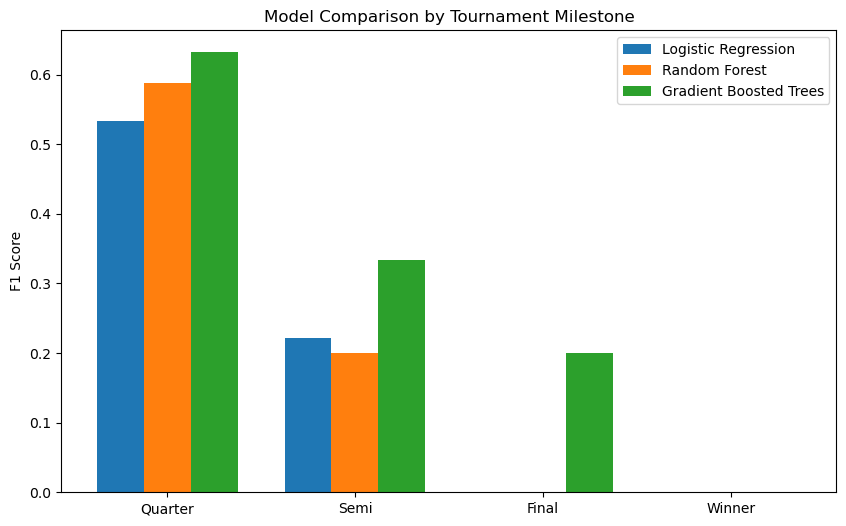

In [119]:
import matplotlib.pyplot as plt
import numpy as np

targets = [
    "quarter_finalist",
    "semi_finalist",
    "finalist",
    "winner"
]

models = [
    "Logistic Regression",
    "Random Forest",
    "Gradient Boosted Trees"
]

x = np.arange(len(targets))
width = 0.25

plt.figure(figsize=(10,6))

for i, model in enumerate(models):

    scores = []

    for target in targets:

        value = results_pd[
            (results_pd["model"] == model) &
            (results_pd["target"] == target)
        ]["F1"].iloc[0]

        scores.append(value)

    plt.bar(
        x + i*width,
        scores,
        width,
        label=model
    )

plt.xticks(
    x + width,
    [
        "Quarter",
        "Semi",
        "Final",
        "Winner"
    ]
)

plt.ylabel("F1 Score")
plt.title("Model Comparison by Tournament Milestone")
plt.legend()

plt.show()

### Model Comparison

The three machine learning algorithms exhibited different strengths across the
four prediction tasks.

Random Forest achieved the highest AUROC (0.91) for predicting quarter-finalists,
indicating the strongest ability to distinguish between advancing and
non-advancing teams across a range of classification thresholds. Gradient
Boosted Trees achieved the highest F1 score (0.63) for the same task by
correctly identifying six of the eight quarter-finalists in the 2022 World Cup.

For the semi-final and finalist prediction tasks, Gradient Boosted Trees
produced the strongest positive-class performance. It was the only model that
successfully identified a finalist, demonstrating a greater ability to detect
rare advancement outcomes than the other classifiers.

All three models struggled to predict the tournament winner because only five
historical champions were available for training. This severe class imbalance
limited the ability of every classifier to identify positive cases at the
default probability threshold.

Overall, the tree-based models consistently outperformed Logistic Regression,
demonstrating that nonlinear relationships among the predictor variables
provided additional predictive value. Although Random Forest achieved the
highest AUROC for quarter-final prediction, Gradient Boosted Trees delivered the
strongest overall balance of precision, recall, and F1 score across the
advancement milestones and was therefore selected as the final model for
predicting the 2026 FIFA World Cup.

### Champion Model Selection

Although no single algorithm dominated every evaluation metric, Gradient
Boosted Trees demonstrated the strongest overall performance across the four
prediction tasks.

Gradient Boosted Trees achieved:

- the highest F1 score for quarter-final prediction,
- the highest F1 score for semi-final prediction,
- the only successful finalist prediction,
- competitive AUROC values across all targets.

Random Forest achieved the highest AUROC for quarter-final prediction and
provided excellent ranking performance, but Gradient Boosted Trees produced
better positive-class identification overall.

For these reasons, Gradient Boosted Trees was selected as the final model for
predicting the 2026 FIFA World Cup.

### Model Limitations

Several limitations should be considered when interpreting the results.

The historical dataset contains only six completed World Cup tournaments,
providing 192 observations for model development. This limited sample size is
particularly challenging for predicting finalists and tournament champions,
where only ten finalists and five winners were available for training.

Additionally, some Elo ratings and squad market values required imputation due
to missing historical data. Although median imputation and missing-value
indicator variables were incorporated into the preprocessing pipeline, these
approaches cannot fully replace unavailable historical information.

Finally, tournament outcomes are influenced by injuries, player availability,
matchups, and other unpredictable events that cannot be fully captured using
pre-tournament statistics alone.

## 13. 2026 FIFA World Cup Predictions

The final Gradient Boosted Tree models are applied to the 2026 World Cup
dataset.

For each participating nation, the models estimate the probability of reaching:

- Quarter-finals
- Semi-finals
- Final
- Tournament Champion

These predictions are intended to demonstrate the application of the trained
models and should not be interpreted as guarantees of tournament outcomes.

In [120]:
gbt_prediction_results = {}

for target in target_columns:

    gbt_prediction_results[target] = (
        gbt_models[target]
        .transform(prediction_tree)
    )

In [121]:
from pyspark.ml.functions import vector_to_array

def extract_prediction_probability(df, target):

    return (
        df
        .withColumn(
            f"{target}_probability",
            vector_to_array("probability")[1]
        )
        .select(
            "team",
            F.col(f"{target}_probability")
        )
    )

In [122]:
quarter_probs = extract_prediction_probability(
    gbt_prediction_results["quarter_finalist"],
    "quarter_finalist"
)

semi_probs = extract_prediction_probability(
    gbt_prediction_results["semi_finalist"],
    "semi_finalist"
)

final_probs = extract_prediction_probability(
    gbt_prediction_results["finalist"],
    "finalist"
)

winner_probs = extract_prediction_probability(
    gbt_prediction_results["winner"],
    "winner"
)

In [123]:
prediction_table = (
    quarter_probs
    .join(semi_probs, "team")
    .join(final_probs, "team")
    .join(winner_probs, "team")
)

In [133]:
prediction_table.select(
    "team",
    F.round("quarter_finalist_probability",3).alias("Probability")
).orderBy(
    F.desc("Probability")
).show(10, truncate=False)

+-----------+-----------+
|team       |Probability|
+-----------+-----------+
|Ecuador    |0.998      |
|Uruguay    |0.908      |
|Paraguay   |0.852      |
|Spain      |0.8        |
|Switzerland|0.789      |
|Belgium    |0.775      |
|Norway     |0.729      |
|Sweden     |0.719      |
|Netherlands|0.69       |
|Ghana      |0.689      |
+-----------+-----------+
only showing top 10 rows


In [145]:
prediction_table.select(
    "team",
    F.round("semi_finalist_probability",3).alias("Probability")
).orderBy(
    F.desc("Probability")
).show(10, truncate=False)

+-----------+-----------+
|team       |Probability|
+-----------+-----------+
|Netherlands|0.933      |
|Ecuador    |0.913      |
|France     |0.883      |
|Uruguay    |0.87       |
|Norway     |0.788      |
|Spain      |0.717      |
|Germany    |0.698      |
|Portugal   |0.642      |
|Ivory Coast|0.439      |
|Morocco    |0.418      |
+-----------+-----------+
only showing top 10 rows


In [146]:
prediction_table.select(
    "team",
    F.round("finalist_probability",3).alias("Probability")
).orderBy(
    F.desc("Probability")
).show(10, truncate=False)

+-------------+-----------+
|team         |Probability|
+-------------+-----------+
|Mexico       |0.935      |
|Ecuador      |0.912      |
|Uruguay      |0.79       |
|United States|0.753      |
|Morocco      |0.59       |
|Senegal      |0.59       |
|Ivory Coast  |0.469      |
|Egypt        |0.443      |
|Canada       |0.422      |
|South Africa |0.422      |
+-------------+-----------+
only showing top 10 rows


In [147]:
prediction_table.select(
    "team",
    F.round("winner_probability",3).alias("Probability")
).orderBy(
    F.desc("Probability")
).show(10, truncate=False)

+-----------+-----------+
|team       |Probability|
+-----------+-----------+
|Paraguay   |0.022      |
|Senegal    |0.022      |
|Sweden     |0.022      |
|Turkey     |0.022      |
|Iraq       |0.022      |
|Germany    |0.022      |
|Ivory Coast|0.022      |
|Jordan     |0.022      |
|France     |0.022      |
|DR Congo   |0.022      |
+-----------+-----------+
only showing top 10 rows


### 2026 World Cup Predictions

The Gradient Boosted Tree models were applied to the 2026 tournament dataset to estimate the probability that each team would advance to the quarter-finals, semi-finals, and final. The resulting rankings generally favored teams with strong historical World Cup performance, high Elo ratings, and valuable squads, while also identifying several emerging teams with favorable advancement probabilities.

The quarter-final and semi-final models produced a range of predicted probabilities across participating teams, indicating meaningful separation between likely contenders and less favored teams. The finalist model also identified a subset of teams with substantially higher advancement probabilities, although predictions should be interpreted cautiously because of the limited historical sample available for training.

In contrast, the tournament winner model assigned nearly identical probabilities to all teams. This reflects the difficulty of learning the champion outcome from only six historical tournaments and five positive training examples. Consequently, the winner predictions are not considered sufficiently reliable for interpretation, and the quarter-final, semi-final, and finalist models provide more meaningful insights into expected tournament performance.

# 14. Conclusion

### Project Summary

The objective of this project was to develop machine learning models capable of
predicting team advancement in the FIFA World Cup using historical
pre-tournament data. Historical tournament data from the 2002 through 2022 FIFA
World Cups were combined with team performance statistics, FIFA rankings,
Transfermarkt squad valuations, and historical Elo ratings to create a
comprehensive dataset for model development.

After cleaning the data, handling missing values, engineering features, and
building reusable Spark ML preprocessing pipelines, three classification
algorithms were developed and evaluated: Logistic Regression, Random Forest,
and Gradient Boosted Trees. Each algorithm was trained to predict four separate
tournament milestones: quarter-finalist, semi-finalist, finalist, and
tournament champion. Model performance was evaluated using a chronological
train-test split, with tournaments from 2002–2018 used for training and the
2022 FIFA World Cup reserved as an independent test set.

### Key Findings

The tree-based models consistently outperformed the Logistic Regression
benchmark, demonstrating that nonlinear machine learning methods were better
suited for modeling the complex relationships among historical performance,
team quality, and tournament advancement.

Random Forest achieved the highest AUROC for quarter-final prediction,
indicating strong discrimination between advancing and non-advancing teams.
Gradient Boosted Trees produced the strongest overall classification
performance, achieving the highest F1 scores for quarter-final and semi-final
prediction while also being the only model to correctly identify a finalist in
the held-out 2022 tournament.

The trained Gradient Boosted Tree models were subsequently applied to the 2026
FIFA World Cup dataset to generate probabilistic predictions for tournament
advancement. These predictions illustrate how machine learning models can be
used to estimate tournament outcomes based solely on information available
before the competition begins.

### Limitations

Several limitations should be considered when interpreting these results.

First, the historical dataset contained only six completed World Cup
tournaments, resulting in a relatively small training sample of 160 teams.
This limitation was particularly severe for predicting finalists and tournament
champions, where only ten finalists and five winners were available for model
training. Consequently, the winner model demonstrated limited predictive
capability.

Second, some historical variables required imputation because of unavailable
market value and Elo data. Although median imputation and missing-value
indicator variables were incorporated into the preprocessing pipeline, these
approaches cannot fully replace missing historical information.

Finally, World Cup outcomes depend on many factors that are not represented in
the dataset, including player injuries, squad selection decisions, tournament
draws, managerial changes, and in-match events. These unpredictable factors
limit the accuracy of any model based exclusively on historical
pre-tournament statistics.

### Future Work

Future research could improve predictive performance by incorporating richer
player-level and match-level information. Features such as player availability,
club performance, expected goals (xG), recent international form, betting odds,
and more detailed Elo or SPI ratings may provide additional predictive power.

The models could also benefit from a larger historical dataset as additional
World Cup tournaments become available. Alternative machine learning approaches,
including XGBoost, LightGBM, CatBoost, and neural network architectures, could
also be investigated and compared with the tree-based methods developed in this
project.

Despite its limitations, this project demonstrates that machine learning can
provide meaningful probabilistic estimates of World Cup advancement using
historical team characteristics available before the tournament begins.